# TP — Churn de Clientes: Análisis Exploratorio de Datos (EDA)
## Inteligencia Artificial Aplicada a Negocios — Q1 2026

---

### Contexto del negocio

Somos analistas de retención en una empresa de e-commerce con **5.630 clientes activos**.  
El año pasado se fue cerca del **17% de la base**.  

**Pregunta central del gerente comercial:**  
> *¿Podemos detectar qué clientes están por irse, antes de que dejen de comprar? ¿Por qué nos dejan?*

### Objetivo de este notebook
Entender el dataset **antes** de modelar. No construimos nada predictivo todavía: primero miramos qué hay, cómo se distribuye, qué relaciones existen y formulamos hipótesis con lógica de negocio.

### ¿Qué significa churn económicamente?
- Adquirir un cliente nuevo cuesta **5-7 veces más** que retener uno existente.
- Si el gerente puede saber **antes** quién va a irse, puede actuar: ofrecer descuentos, atención personalizada, mejoras en el servicio.
- Con 17% de churn sobre 5.630 clientes = ~957 clientes perdidos por año.
- Si el ticket promedio anual es $X, retener aunque sea el 30% de ellos tiene un impacto significativo en ingresos.

---
## 0. Setup: Importación de librerías

In [1]:
# Librerías estándar de análisis de datos
import pandas as pd
import numpy as np

# Módulo de preparación del proyecto (fuente única de la limpieza de datos)
import sys
sys.path.append('..')
from src import preprocessing as prep

# Visualización
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Tests estadísticos
from scipy import stats

# Configuraciones de display
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Estilo de gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

# Colores fijos para churn (0=sigue, 1=se fue)
CHURN_COLORS = {0: '#2ecc71', 1: '#e74c3c'}  # verde = activo, rojo = churneó

print('✅ Setup completo. Librerías importadas.')

✅ Setup completo. Librerías importadas.


---
## 1. Carga de datos

> **Instrucción:** Colocá el archivo CSV en `../data/raw/E_Commerce_Dataset.csv` antes de correr esta celda.

In [2]:
# Carga del dataset
DATA_PATH = '/Users/tomasattas/Desktop/churn_tp/data/raw/E_Commerce_Dataset.csv'

df = pd.read_csv(DATA_PATH)

print(f'✅ Dataset cargado correctamente')
print(f'   Filas: {df.shape[0]:,}')
print(f'   Columnas: {df.shape[1]}')

✅ Dataset cargado correctamente
   Filas: 5,630
   Columnas: 20


In [3]:
# Primeras 5 filas para chequear que cargó bien
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.00,Mobile Phone,3,6.00,Debit Card,Female,3.00,3,Laptop & Accessory,2,Single,9,1,11.00,1.00,1.00,5.00,160
1,50002,1,NaN,Phone,1,8.00,UPI,Male,3.00,4,Mobile,3,Single,7,1,15.00,0.00,1.00,0.00,121
2,50003,1,NaN,Phone,1,30.00,Debit Card,Male,2.00,4,Mobile,3,Single,6,1,14.00,0.00,1.00,3.00,120
3,50004,1,0.00,Phone,3,15.00,Debit Card,Male,2.00,4,Laptop & Accessory,5,Single,8,0,23.00,0.00,1.00,3.00,134
4,50005,1,0.00,Phone,1,12.00,CC,Male,NaN,3,Mobile,5,Single,3,0,11.00,1.00,1.00,3.00,130


---
## 2. Comprensión inicial del dataset

### 2.1 Tipos de datos y estructura

In [4]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [5]:
# Estadísticas descriptivas para variables numéricas
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])

,count,mean,std,min,25%,50%,75%,max
CustomerID,5630.000000,52815.500000,1625.385339,50001.000000,51408.250000,52815.500000,54222.750000,55630.000000
Churn,5630.000000,0.168384,0.374240,0.000000,0.000000,0.000000,0.000000,1.000000
Tenure,5366.000000,10.189899,8.557241,0.000000,2.000000,9.000000,16.000000,61.000000
CityTier,5630.000000,1.654707,0.915389,1.000000,1.000000,1.000000,3.000000,3.000000
WarehouseToHome,5379.000000,15.639896,8.531475,5.000000,9.000000,14.000000,20.000000,127.000000
HourSpendOnApp,5375.000000,2.931535,0.721926,0.000000,2.000000,3.000000,3.000000,5.000000
NumberOfDeviceRegistered,5630.000000,3.688988,1.023999,1.000000,3.000000,4.000000,4.000000,6.000000
SatisfactionScore,5630.000000,3.066785,1.380194,1.000000,2.000000,3.000000,4.000000,5.000000
NumberOfAddress,5630.000000,4.214032,2.583586,1.000000,2.000000,3.000000,6.000000,22.000000
Complain,5630.000000,0.284902,0.451408,0.000000,0.000000,0.000000,1.000000,1.000000


### 2.2 Identificación de valores nulos

El assignment menciona 7 columnas con NaN. Verificamos cuáles son y cuánto afectan.

Columnas con valores nulos:
                             Nulos  % del total
DaySinceLastOrder              307         5.45
OrderAmountHikeFromlastYear    265         4.71
Tenure                         264         4.69
OrderCount                     258         4.58
CouponUsed                     256         4.55
HourSpendOnApp                 255         4.53
WarehouseToHome                251         4.46


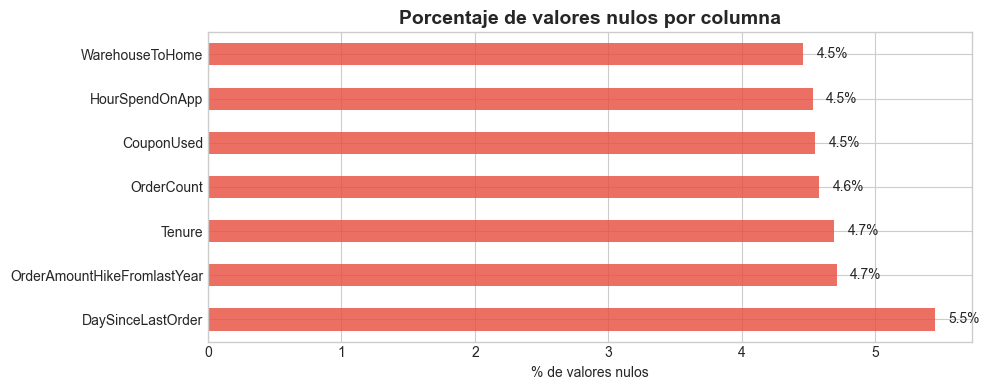

In [6]:
# Análisis de valores nulos
nulos = pd.DataFrame({
    'Nulos': df.isnull().sum(),
    '% del total': (df.isnull().sum() / len(df) * 100).round(2)
})
nulos = nulos[nulos['Nulos'] > 0].sort_values('% del total', ascending=False)

print('Columnas con valores nulos:')
print(nulos)

# Visualización de nulos
fig, ax = plt.subplots(figsize=(10, 4))
nulos['% del total'].plot(kind='barh', ax=ax, color='#e74c3c', alpha=0.8)
ax.set_xlabel('% de valores nulos')
ax.set_title('Porcentaje de valores nulos por columna', fontsize=14, fontweight='bold')
for i, v in enumerate(nulos['% del total']):
    ax.text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('../reports/nulos.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretación de negocio:** 
Los nulos en Tenure, HourSpendOnApp y OrderCount son problemáticos porque son variables clave para predecir churn. No son datos que "no existen" — probablemente son errores de registro o clientes muy nuevos sin historial suficiente. Deberemos decidir si imputar (rellenar con la mediana/moda) o eliminar esas filas en la etapa de modelado.

### 2.3 Problemas de calidad de datos — Categorías inconsistentes

Un EDA riguroso detecta categorías que deberían ser iguales pero están escritas diferente.

In [7]:
# Revisión de variables categóricas
cat_cols = df.select_dtypes(include='object').columns
print('=== Valores únicos por variable categórica ===')
for col in cat_cols:
    valores = df[col].value_counts()
    print(f'\n{col}:')
    print(valores.to_string())

=== Valores únicos por variable categórica ===

PreferredLoginDevice:
PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231

PreferredPaymentMode:
PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149

Gender:
Gender
Male      3384
Female    2246

PreferedOrderCat:
PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone          1271
Fashion                826
Mobile                 809
Grocery                410
Others                 264

MaritalStatus:
MaritalStatus
Married     2986
Single      1796
Divorced     848


In [8]:
# ⚠️ PROBLEMA DETECTADO: Categorías duplicadas (misma categoría escrita de formas distintas)
#   PreferredPaymentMode: 'CC'/'Credit Card', 'COD'/'Cash on Delivery'
#   PreferredLoginDevice: 'Phone'/'Mobile Phone'
#   PreferedOrderCat:     'Mobile'/'Mobile Phone'

cols_dup = ['PreferredPaymentMode', 'PreferredLoginDevice', 'PreferedOrderCat']
print('=== Antes de unificar ===')
for col in cols_dup:
    print(f'{col}: {df[col].unique().tolist()}')

# Unificamos con la función compartida de src/preprocessing.py.
# Misma lógica que usa la preparación de datos -> una sola fuente de verdad, sin duplicar código.
df = prep.clean_categories(df)

print('\n=== Después de unificar ===')
for col in cols_dup:
    print(f'{col}: {df[col].unique().tolist()}')

# Guardamos el dataset limpio: esta es la ÚNICA limpieza de categorías del proyecto.
# La preparación de datos (02) carga este archivo y NO vuelve a limpiar (sin duplicar).
df.to_csv('../data/processed/dataset_limpio.csv', index=False)
print('\n💾 Dataset limpio guardado en data/processed/dataset_limpio.csv')


=== Antes de unificar ===
PreferredPaymentMode: ['Debit Card', 'UPI', 'CC', 'Cash on Delivery', 'E wallet', 'COD', 'Credit Card']
PreferredLoginDevice: ['Mobile Phone', 'Phone', 'Computer']
PreferedOrderCat: ['Laptop & Accessory', 'Mobile', 'Mobile Phone', 'Others', 'Fashion', 'Grocery']

=== Después de unificar ===
PreferredPaymentMode: ['Debit Card', 'UPI', 'Credit Card', 'Cash on Delivery', 'E wallet']
PreferredLoginDevice: ['Mobile Phone', 'Computer']
PreferedOrderCat: ['Laptop & Accessory', 'Mobile Phone', 'Others', 'Fashion', 'Grocery']

💾 Dataset limpio guardado en data/processed/dataset_limpio.csv


---
## 3. Variable target: Distribución del Churn

Antes de analizar las features, necesitamos entender el desbalance de clases (class imbalance).

=== Distribución de Churn ===
  Clientes activos (0): 4,682 (83.2%)
  Clientes que churnearon (1): 948 (16.8%)

⚠️  CLASS IMBALANCE: 83% vs 17%
   Esto significa que si un modelo predice "nadie churna", acertaría el 83% de las veces.
   Por eso NO usamos Accuracy como métrica principal.


/var/folders/7x/3cdzp16s07z67v5rp0v7f6zm0000gn/T/ipykernel_707/1884195526.py:27: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7x/3cdzp16s07z67v5rp0v7f6zm0000gn/T/ipykernel_707/1884195526.py:27: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
/Users/tomasattas/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/tomasattas/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


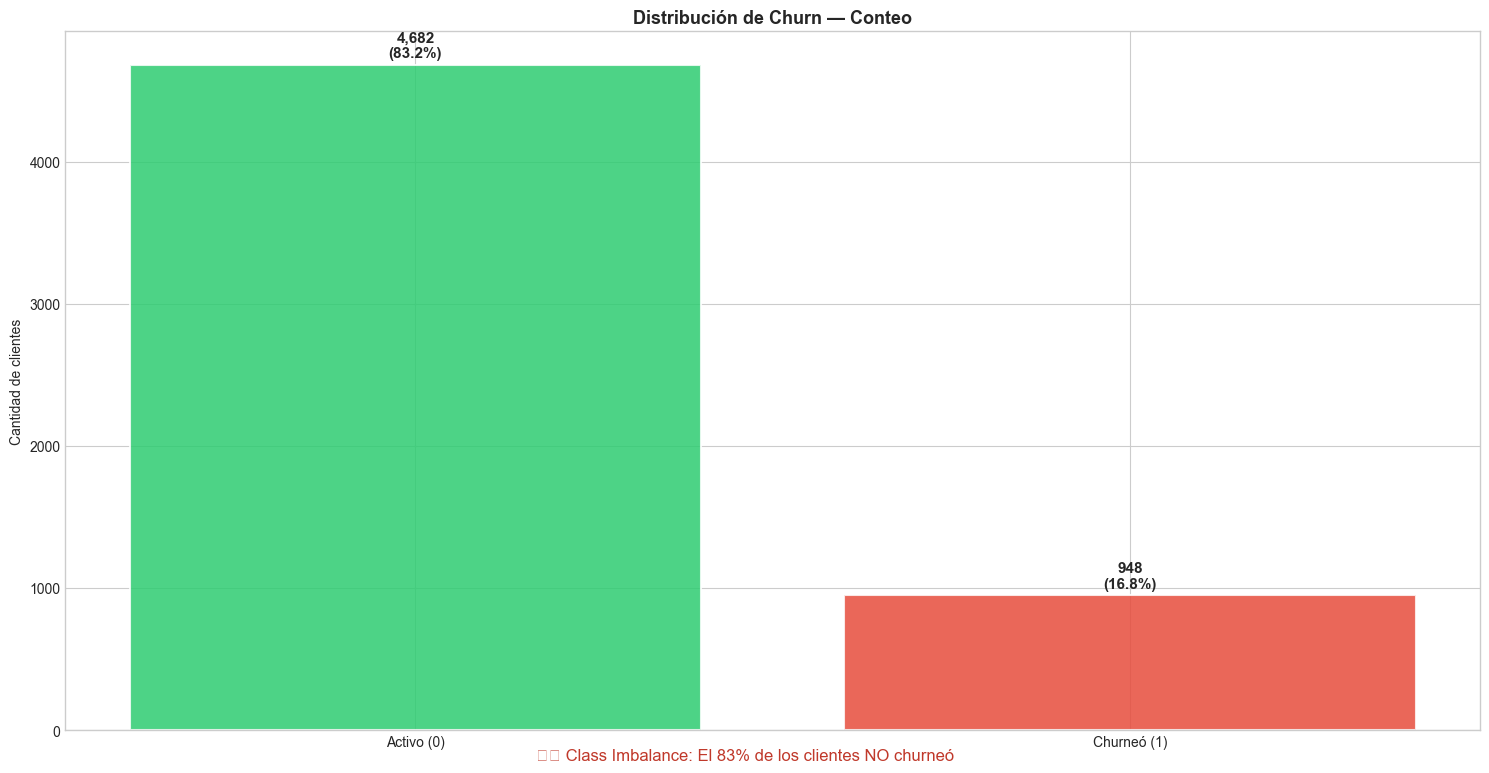

In [9]:
# Distribución de churn
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print('=== Distribución de Churn ===')
print(f'  Clientes activos (0): {churn_counts[0]:,} ({churn_pct[0]:.1f}%)')
print(f'  Clientes que churnearon (1): {churn_counts[1]:,} ({churn_pct[1]:.1f}%)')
print()
print(f'⚠️  CLASS IMBALANCE: {churn_pct[0]:.0f}% vs {churn_pct[1]:.0f}%')
print('   Esto significa que si un modelo predice "nadie churna", acertaría el 83% de las veces.')
print('   Por eso NO usamos Accuracy como métrica principal.')

# Gráfico
fig, (ax1) = plt.subplots(1, figsize=(15, 8))

# Barras
bars = ax1.bar(['Activo (0)', 'Churneó (1)'], churn_counts.values, 
               color=[CHURN_COLORS[0], CHURN_COLORS[1]], alpha=0.85, edgecolor='white', linewidth=1.5)
ax1.set_title('Distribución de Churn — Conteo', fontsize=13, fontweight='bold')
ax1.set_ylabel('Cantidad de clientes')
for bar, count, pct in zip(bars, churn_counts.values, churn_pct.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30, 
             f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('⚠️ Class Imbalance: El 83% de los clientes NO churneó', 
             fontsize=12, color='#c0392b', y=0.02)
plt.tight_layout()
plt.show()

---
## 4. Análisis de variables numéricas

### 4.1 Detección de outliers

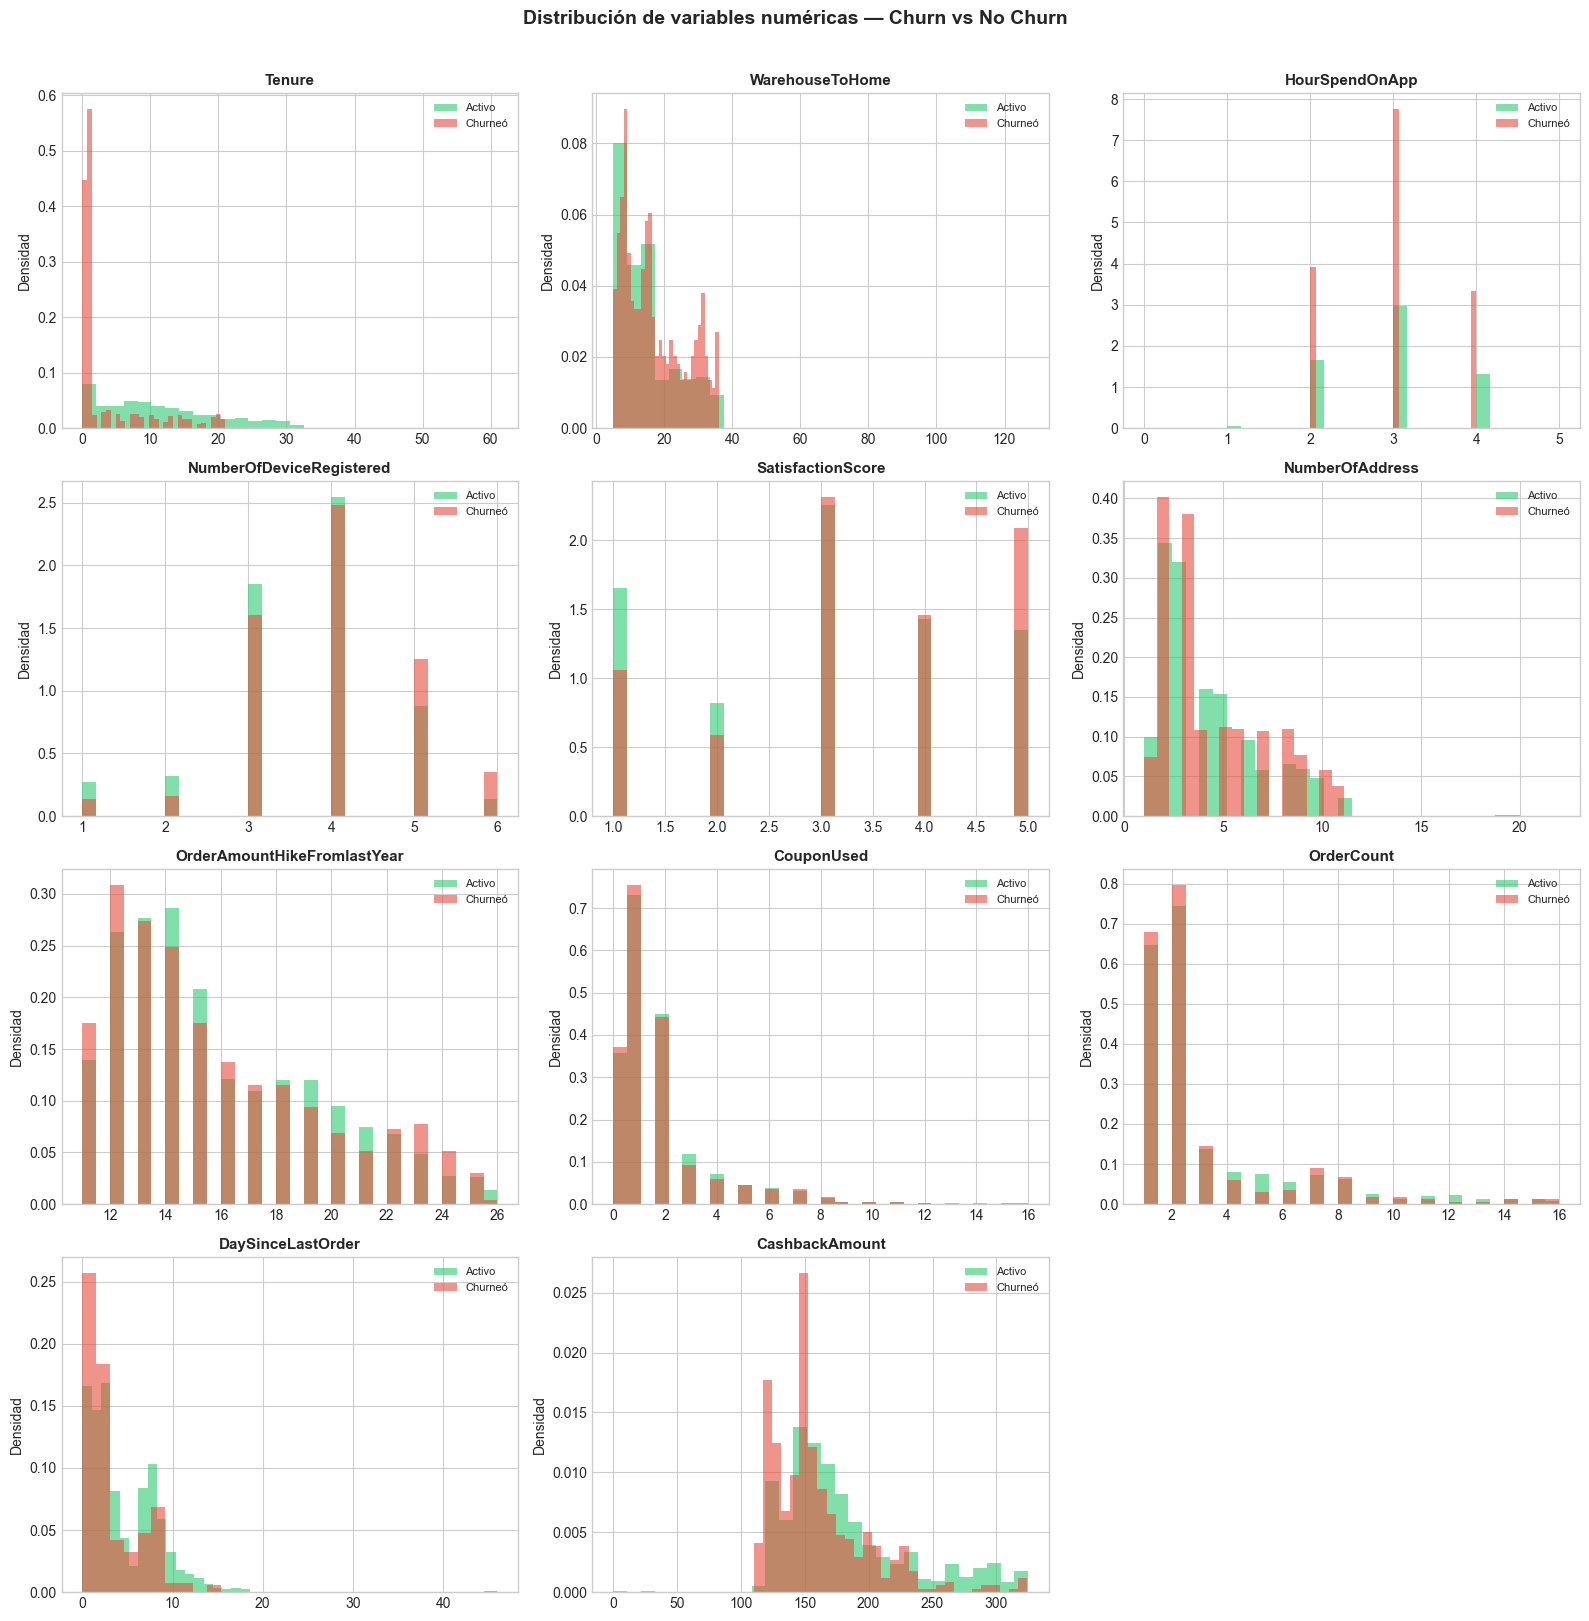

In [10]:
# Variables numéricas (sin CustomerID y Churn)
num_cols = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered',
            'SatisfactionScore', 'NumberOfAddress', 'OrderAmountHikeFromlastYear',
            'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

fig, axes = plt.subplots(4, 3, figsize=(16, 16))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    # Separamos por churn
    data0 = df[df['Churn'] == 0][col].dropna()
    data1 = df[df['Churn'] == 1][col].dropna()
    
    ax.hist(data0, bins=30, alpha=0.6, color=CHURN_COLORS[0], label='Activo', density=True)
    ax.hist(data1, bins=30, alpha=0.6, color=CHURN_COLORS[1], label='Churneó', density=True)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_ylabel('Densidad')

# Ocultar el subplot extra
axes[-1].set_visible(False)

plt.suptitle('Distribución de variables numéricas — Churn vs No Churn', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/distribuciones_numericas.png', dpi=150, bbox_inches='tight')
plt.show()

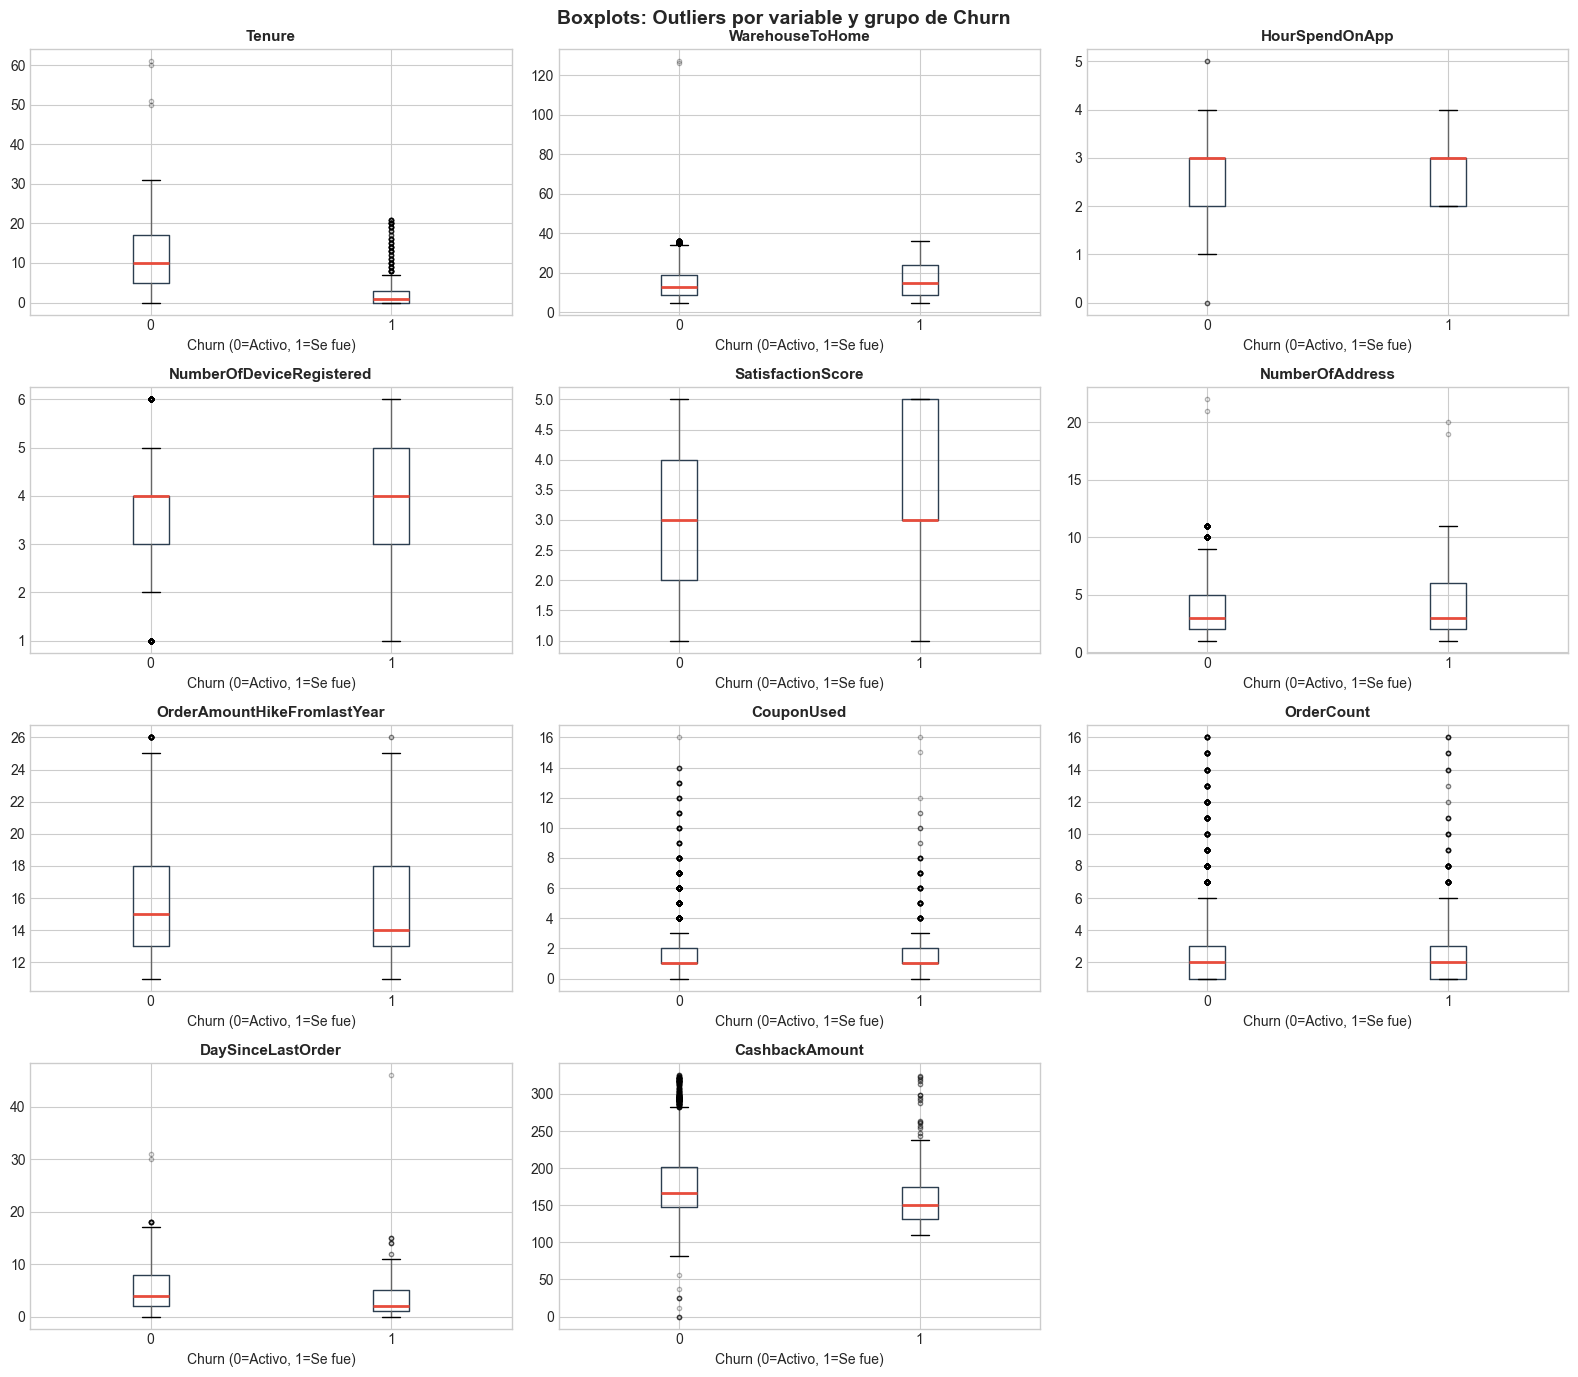

In [11]:
# Detección de outliers con boxplots
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    df.boxplot(column=col, by='Churn', ax=ax,
               boxprops=dict(color='#2c3e50'),
               medianprops=dict(color='#e74c3c', linewidth=2),
               flierprops=dict(marker='o', alpha=0.3, markersize=3))
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('Churn (0=Activo, 1=Se fue)')
    ax.set_ylabel('')

axes[-1].set_visible(False)
plt.suptitle('Boxplots: Outliers por variable y grupo de Churn', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/boxplots_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Resumen de outliers detectados
print('=== OUTLIERS DETECTADOS - Análisis por columna ===')
for col in num_cols:
    serie = df[col].dropna()
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = serie[(serie < lower) | (serie > upper)]
    if len(outliers) > 0:
        print(f'\n{col}:')
        print(f'  Rango normal: [{lower:.1f}, {upper:.1f}]')
        print(f'  Outliers: {len(outliers)} registros ({len(outliers)/len(serie)*100:.1f}%)')
        print(f'  Valores extremos: min={outliers.min():.1f}, max={outliers.max():.1f}')

=== OUTLIERS DETECTADOS - Análisis por columna ===

Tenure:
  Rango normal: [-19.0, 37.0]
  Outliers: 4 registros (0.1%)
  Valores extremos: min=50.0, max=61.0

WarehouseToHome:
  Rango normal: [-7.5, 36.5]
  Outliers: 2 registros (0.0%)
  Valores extremos: min=126.0, max=127.0

HourSpendOnApp:
  Rango normal: [0.5, 4.5]
  Outliers: 6 registros (0.1%)
  Valores extremos: min=0.0, max=5.0

NumberOfDeviceRegistered:
  Rango normal: [1.5, 5.5]
  Outliers: 397 registros (7.1%)
  Valores extremos: min=1.0, max=6.0

NumberOfAddress:
  Rango normal: [-4.0, 12.0]
  Outliers: 4 registros (0.1%)
  Valores extremos: min=19.0, max=22.0

OrderAmountHikeFromlastYear:
  Rango normal: [5.5, 25.5]
  Outliers: 33 registros (0.6%)
  Valores extremos: min=26.0, max=26.0

CouponUsed:
  Rango normal: [-0.5, 3.5]
  Outliers: 629 registros (11.7%)
  Valores extremos: min=4.0, max=16.0

OrderCount:
  Rango normal: [-2.0, 6.0]
  Outliers: 703 registros (13.1%)
  Valores extremos: min=7.0, max=16.0

DaySinceLast

**Interpretación de negocio sobre outliers:**
- **Tenure con valores 50-61**: La mayoría de clientes tiene tenure 0-31 meses. Valores de 50-61 son sospechosos — podrían ser errores de carga o clientes muy antiguos en una empresa relativamente nueva.
- **WarehouseToHome con 126-127 km**: La mayoría de distancias son 5-36 km. 126 km es un outlier extremo que puede ser un error de carga de datos.
- **DaySinceLastOrder**: Valores altos (30+) podrían indicar clientes inactivos que ya están en proceso de churn.

---
## 5. Análisis de variables categóricas

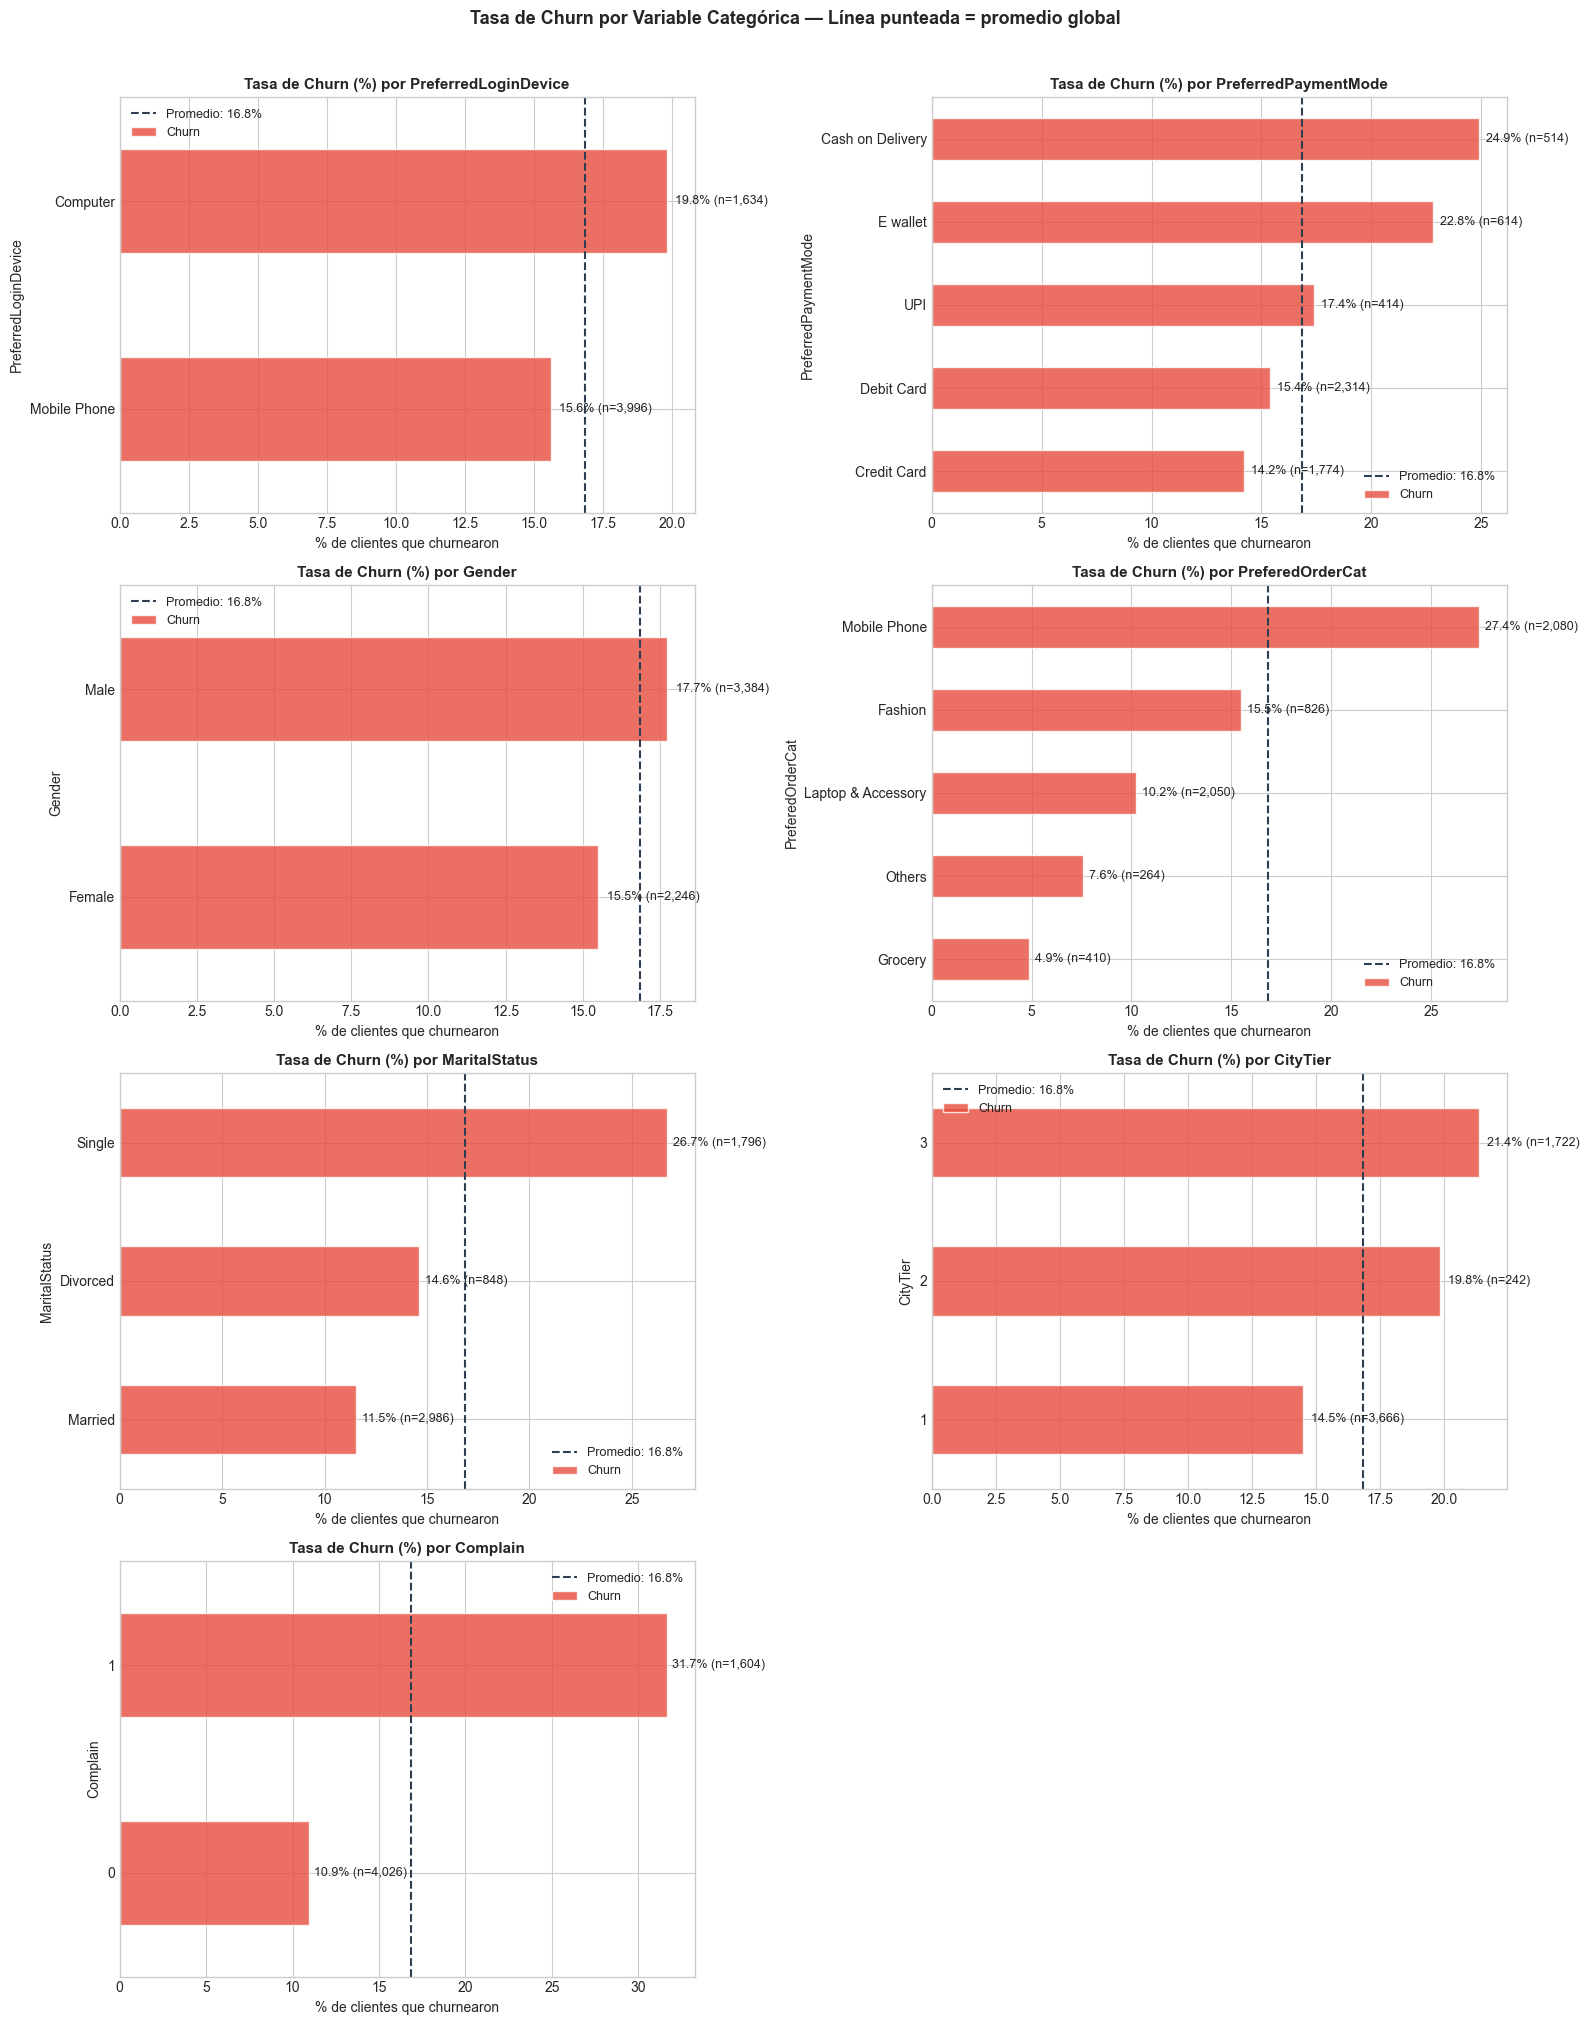

In [13]:
cat_analysis_cols = ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 
                     'PreferedOrderCat', 'MaritalStatus', 'CityTier', 'Complain']

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(cat_analysis_cols):
    ax = axes[i]
    
    # Tasa de churn por categoría
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=True) * 100
    count = df.groupby(col)['Churn'].count()
    
    bars = churn_rate.plot(kind='barh', ax=ax, color='#e74c3c', alpha=0.8, edgecolor='white')
    ax.set_title(f'Tasa de Churn (%) por {col}', fontsize=11, fontweight='bold')
    ax.set_xlabel('% de clientes que churnearon')
    
    # Agregar línea de tasa promedio
    avg_churn = df['Churn'].mean() * 100
    ax.axvline(avg_churn, color='#2c3e50', linestyle='--', linewidth=1.5, 
               label=f'Promedio: {avg_churn:.1f}%')
    ax.legend(fontsize=9)
    
    # Agregar conteos
    for j, (val, rate) in enumerate(churn_rate.items()):
        n = count[val]
        ax.text(rate + 0.3, j, f'{rate:.1f}% (n={n:,})', va='center', fontsize=9)

axes[-1].set_visible(False)
plt.suptitle('Tasa de Churn por Variable Categórica — Línea punteada = promedio global', 
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/churn_por_categoria.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Hipótesis de Negocio

Ahora formulamos hipótesis con lógica de negocio y las verificamos con datos.

### H1: Clientes nuevos (Tenure bajo) tienen mayor riesgo de irse

**Lógica de negocio:** Un cliente que lleva poco tiempo en la plataforma todavía no desarrolló hábito de compra ni lealtad. Es más fácil que pruebe competidores. Los primeros 3-6 meses son críticos para "enganchar" al cliente.

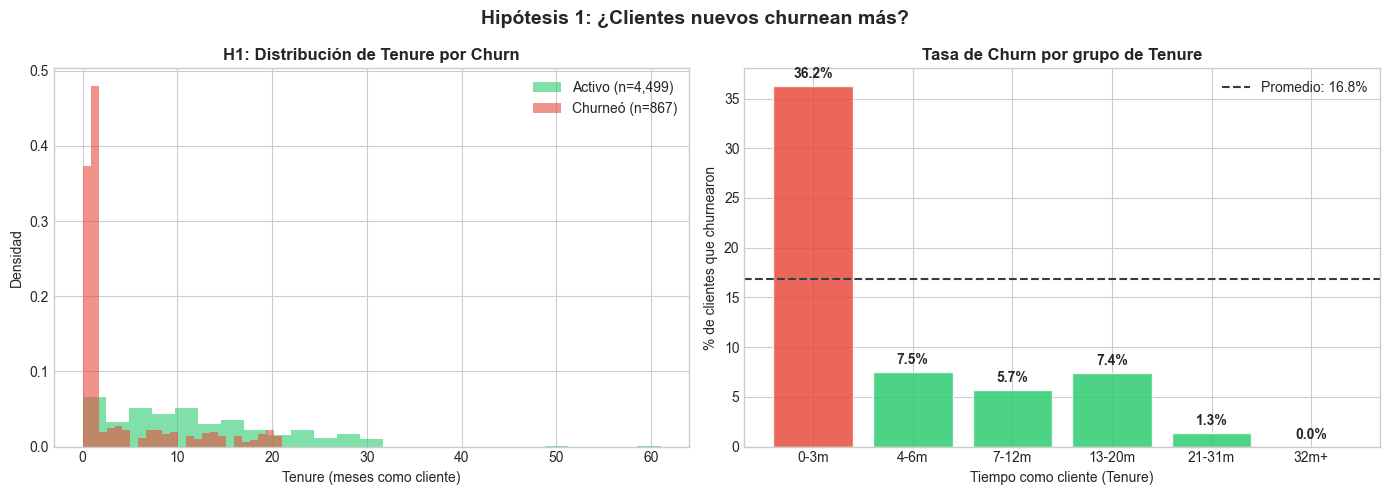

=== TEST ESTADÍSTICO: H1 — Tenure y Churn ===
Tenure promedio clientes activos:  11.5 meses
Tenure promedio clientes churneados: 3.4 meses
Mann-Whitney U — p-value: 0.000000
✅ HIPÓTESIS CONFIRMADA: La diferencia es estadísticamente significativa.
   Los clientes que se fueron tenían tenure significativamente menor.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Distribución de Tenure por Churn
ax = axes[0]
for churn_val, label in [(0, 'Activo'), (1, 'Churneó')]:
    data = df[df['Churn'] == churn_val]['Tenure'].dropna()
    ax.hist(data, bins=25, alpha=0.6, color=CHURN_COLORS[churn_val], 
            label=f'{label} (n={len(data):,})', density=True)
ax.set_xlabel('Tenure (meses como cliente)')
ax.set_ylabel('Densidad')
ax.set_title('H1: Distribución de Tenure por Churn', fontsize=12, fontweight='bold')
ax.legend()

# Gráfico 2: Tasa de churn por bucket de Tenure
ax2 = axes[1]
df_tenure = df.dropna(subset=['Tenure']).copy()
df_tenure['Tenure_grupo'] = pd.cut(
    df_tenure['Tenure'], 
    bins=[0, 3, 6, 12, 20, 31, 100],
    labels=['0-3m', '4-6m', '7-12m', '13-20m', '21-31m', '32m+']
)
churn_by_tenure = df_tenure.groupby('Tenure_grupo', observed=False)['Churn'].mean() * 100
colors = ['#e74c3c' if x > df['Churn'].mean()*100 else '#2ecc71' for x in churn_by_tenure]
bars = ax2.bar(churn_by_tenure.index, churn_by_tenure.values, color=colors, alpha=0.85, edgecolor='white')
ax2.axhline(df['Churn'].mean()*100, color='#2c3e50', linestyle='--', linewidth=1.5, 
             label=f'Promedio: {df["Churn"].mean()*100:.1f}%')
ax2.set_xlabel('Tiempo como cliente (Tenure)')
ax2.set_ylabel('% de clientes que churnearon')
ax2.set_title('Tasa de Churn por grupo de Tenure', fontsize=12, fontweight='bold')
ax2.legend()
for bar, val in zip(bars, churn_by_tenure.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Hipótesis 1: ¿Clientes nuevos churnean más?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/h1_tenure_churn.png', dpi=150, bbox_inches='tight')
plt.show()

# Test estadístico: Mann-Whitney U (no paramétrico, datos no normales)
grupo_churn = df[df['Churn']==1]['Tenure'].dropna()
grupo_activo = df[df['Churn']==0]['Tenure'].dropna()
stat, p_value = stats.mannwhitneyu(grupo_churn, grupo_activo, alternative='less')

print('=== TEST ESTADÍSTICO: H1 — Tenure y Churn ===')
print(f'Tenure promedio clientes activos:  {grupo_activo.mean():.1f} meses')
print(f'Tenure promedio clientes churneados: {grupo_churn.mean():.1f} meses')
print(f'Mann-Whitney U — p-value: {p_value:.6f}')
if p_value < 0.05:
    print('✅ HIPÓTESIS CONFIRMADA: La diferencia es estadísticamente significativa.')
    print('   Los clientes que se fueron tenían tenure significativamente menor.')
else:
    print('❌ No hay evidencia estadística suficiente.')

**Interpretación de negocio (H1):**  
Si la hipótesis se confirma, el equipo de retención debería enfocarse en clientes con menos de 6 meses de tenure. Un programa de onboarding sólido (tutoriales, primer compra con descuento, atención personalizada) en los primeros meses puede reducir significativamente el churn temprano.

### H2: Clientes que se quejaron (Complain = 1) churnean más

**Lógica de negocio:** Una queja es la señal más directa de insatisfacción. Un cliente que se toma el tiempo de quejarse está diciendo "esto no está bien". Si no se resuelve, probablemente se vaya.  

**⚠️ Riesgo de leakage:** Si la queja se registró *después* de que el cliente ya se fue (es decir, es la queja de cierre), entonces esta variable no es útil para predecir — el modelo estaría "viendo el futuro". Hay que verificar con el equipo de datos cuándo se registra Complain.

/var/folders/7x/3cdzp16s07z67v5rp0v7f6zm0000gn/T/ipykernel_707/4218023545.py:35: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7x/3cdzp16s07z67v5rp0v7f6zm0000gn/T/ipykernel_707/4218023545.py:35: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
/Users/tomasattas/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/tomasattas/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


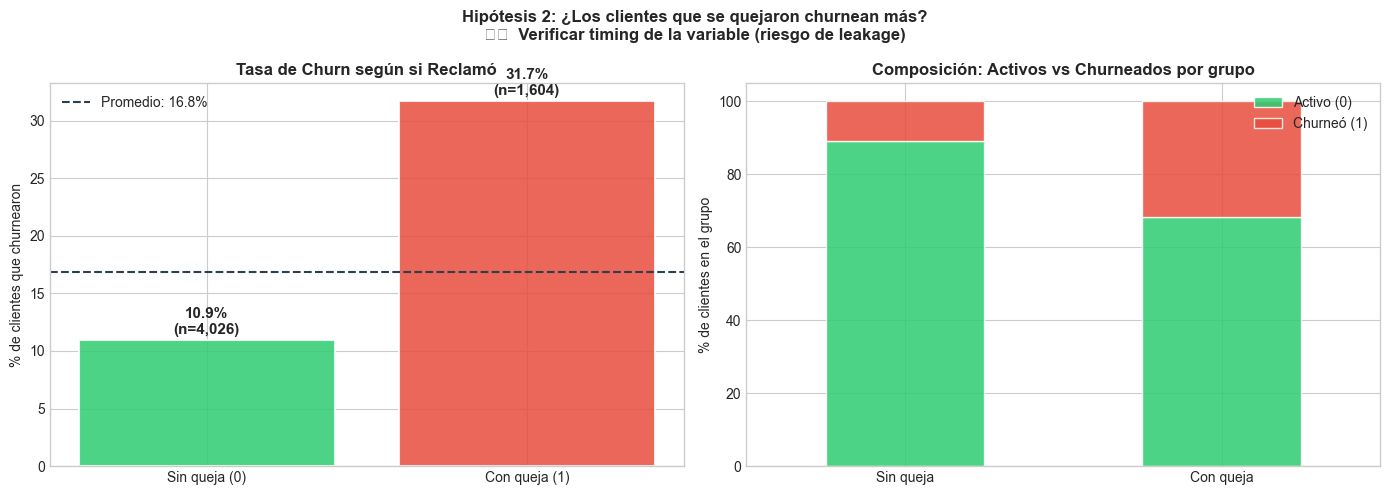

=== TEST ESTADÍSTICO: H2 — Complain y Churn ===
Chi-cuadrado: 350.93, p-value: 0.000000
✅ HIPÓTESIS CONFIRMADA: Hay asociación estadísticamente significativa entre queja y churn.

⚠️  ALERTA DE LEAKAGE:
   Hay que confirmar con el equipo de datos si Complain se registra
   ANTES de que el cliente se vaya (señal legítima) o DESPUÉS (trampa).
   Si es después, esta variable NO puede usarse en el modelo.


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Tasa de churn para queja=0 vs queja=1
ax = axes[0]
churn_by_complain = df.groupby('Complain')['Churn'].agg(['mean', 'count'])
churn_by_complain['mean'] *= 100

bars = ax.bar(['Sin queja (0)', 'Con queja (1)'], 
               churn_by_complain['mean'].values,
               color=[CHURN_COLORS[0], CHURN_COLORS[1]], alpha=0.85, edgecolor='white', linewidth=1.5)
ax.axhline(df['Churn'].mean()*100, color='#2c3e50', linestyle='--', linewidth=1.5,
           label=f'Promedio: {df["Churn"].mean()*100:.1f}%')
ax.set_ylabel('% de clientes que churnearon')
ax.set_title('Tasa de Churn según si Reclamó', fontsize=12, fontweight='bold')
ax.legend()
for bar, val, n in zip(bars, churn_by_complain['mean'].values, churn_by_complain['count'].values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%\n(n={n:,})', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Gráfico 2: Stacked bar de composición
ax2 = axes[1]
tabla = pd.crosstab(df['Complain'], df['Churn'], normalize='index') * 100
tabla.columns = ['Activo (0)', 'Churneó (1)']
tabla.index = ['Sin queja', 'Con queja']
tabla.plot(kind='bar', stacked=True, ax=ax2, 
           color=[CHURN_COLORS[0], CHURN_COLORS[1]], alpha=0.85,
           edgecolor='white')
ax2.set_title('Composición: Activos vs Churneados por grupo', fontsize=12, fontweight='bold')
ax2.set_ylabel('% de clientes en el grupo')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
ax2.legend(loc='upper right')

plt.suptitle('Hipótesis 2: ¿Los clientes que se quejaron churnean más?\n⚠️  Verificar timing de la variable (riesgo de leakage)', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Chi-cuadrado (variable categórica vs categórica)
contingencia = pd.crosstab(df['Complain'], df['Churn'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingencia)

print('=== TEST ESTADÍSTICO: H2 — Complain y Churn ===')
print(f'Chi-cuadrado: {chi2:.2f}, p-value: {p_value:.6f}')
if p_value < 0.05:
    print('✅ HIPÓTESIS CONFIRMADA: Hay asociación estadísticamente significativa entre queja y churn.')
else:
    print('❌ No hay evidencia estadística suficiente.')

print()
print('⚠️  ALERTA DE LEAKAGE:')
print('   Hay que confirmar con el equipo de datos si Complain se registra')
print('   ANTES de que el cliente se vaya (señal legítima) o DESPUÉS (trampa).')
print('   Si es después, esta variable NO puede usarse en el modelo.')

### H3: Clientes con muchos días sin comprar están más cerca de irse

**Lógica de negocio:** La inactividad es una señal silenciosa de desenganche. Un cliente que no compra hace 30 días en una plataforma de e-commerce probablemente encontró una alternativa o perdió el interés.

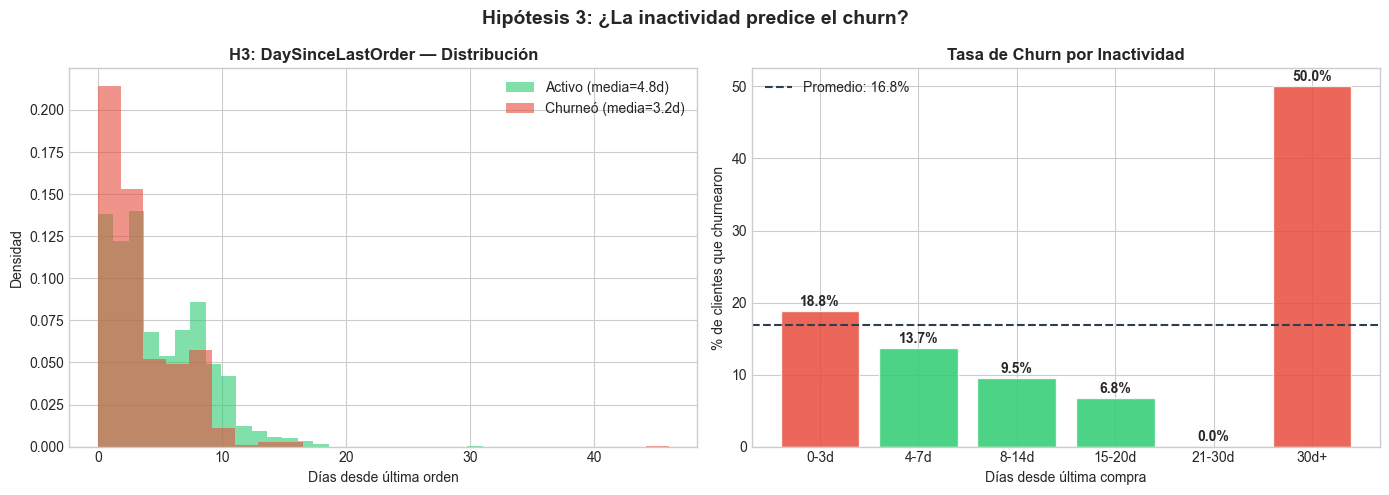

=== TEST ESTADÍSTICO: H3 — DaySinceLastOrder y Churn ===
Días sin comprar (activos):   4.8 días (mediana: 4.0)
Días sin comprar (churneados): 3.2 días (mediana: 2.0)
Mann-Whitney U — p-value: 1.000000
❌ No hay evidencia estadística suficiente. El resultado es sorpresivo — revisar.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Distribución de DaySinceLastOrder
ax = axes[0]
for churn_val, label in [(0, 'Activo'), (1, 'Churneó')]:
    data = df[df['Churn'] == churn_val]['DaySinceLastOrder'].dropna()
    ax.hist(data, bins=25, alpha=0.6, color=CHURN_COLORS[churn_val], 
            label=f'{label} (media={data.mean():.1f}d)', density=True)
ax.set_xlabel('Días desde última orden')
ax.set_ylabel('Densidad')
ax.set_title('H3: DaySinceLastOrder — Distribución', fontsize=12, fontweight='bold')
ax.legend()

# Gráfico 2: Churn rate por bucket de días
ax2 = axes[1]
df_days = df.dropna(subset=['DaySinceLastOrder']).copy()
df_days['Days_grupo'] = pd.cut(
    df_days['DaySinceLastOrder'],
    bins=[0, 3, 7, 14, 20, 30, 100],
    labels=['0-3d', '4-7d', '8-14d', '15-20d', '21-30d', '30d+']
)
churn_by_days = df_days.groupby('Days_grupo', observed=False)['Churn'].mean() * 100
colors = ['#e74c3c' if x > df['Churn'].mean()*100 else '#2ecc71' for x in churn_by_days]
bars = ax2.bar(churn_by_days.index, churn_by_days.values, color=colors, alpha=0.85, edgecolor='white')
ax2.axhline(df['Churn'].mean()*100, color='#2c3e50', linestyle='--', linewidth=1.5,
            label=f'Promedio: {df["Churn"].mean()*100:.1f}%')
ax2.set_xlabel('Días desde última compra')
ax2.set_ylabel('% de clientes que churnearon')
ax2.set_title('Tasa de Churn por Inactividad', fontsize=12, fontweight='bold')
ax2.legend()
for bar, val in zip(bars, churn_by_days.values):
    if not np.isnan(val):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Hipótesis 3: ¿La inactividad predice el churn?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/h3_inactividad_churn.png', dpi=150, bbox_inches='tight')
plt.show()

# Test estadístico
grupo_churn = df[df['Churn']==1]['DaySinceLastOrder'].dropna()
grupo_activo = df[df['Churn']==0]['DaySinceLastOrder'].dropna()
stat, p_value = stats.mannwhitneyu(grupo_churn, grupo_activo, alternative='greater')

print('=== TEST ESTADÍSTICO: H3 — DaySinceLastOrder y Churn ===')
print(f'Días sin comprar (activos):   {grupo_activo.mean():.1f} días (mediana: {grupo_activo.median():.1f})')
print(f'Días sin comprar (churneados): {grupo_churn.mean():.1f} días (mediana: {grupo_churn.median():.1f})')
print(f'Mann-Whitney U — p-value: {p_value:.6f}')
if p_value < 0.05:
    print('✅ HIPÓTESIS CONFIRMADA: Los churneados tenían más días sin comprar.')
else:
    print('❌ No hay evidencia estadística suficiente. El resultado es sorpresivo — revisar.')

### H4: La insatisfacción (SatisfactionScore bajo) predice churn

**Lógica de negocio:** Esta es la hipótesis más "obvia" — la que cualquier persona de negocio asumiría. Pero los datos pueden sorprendernos: a veces clientes insatisfechos se quedan (no tienen alternativa) y clientes satisfechos se van (por precio o conveniencia).

/var/folders/7x/3cdzp16s07z67v5rp0v7f6zm0000gn/T/ipykernel_707/579606473.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_to_plot, labels=['Activo (0)', 'Churneó (1)'],


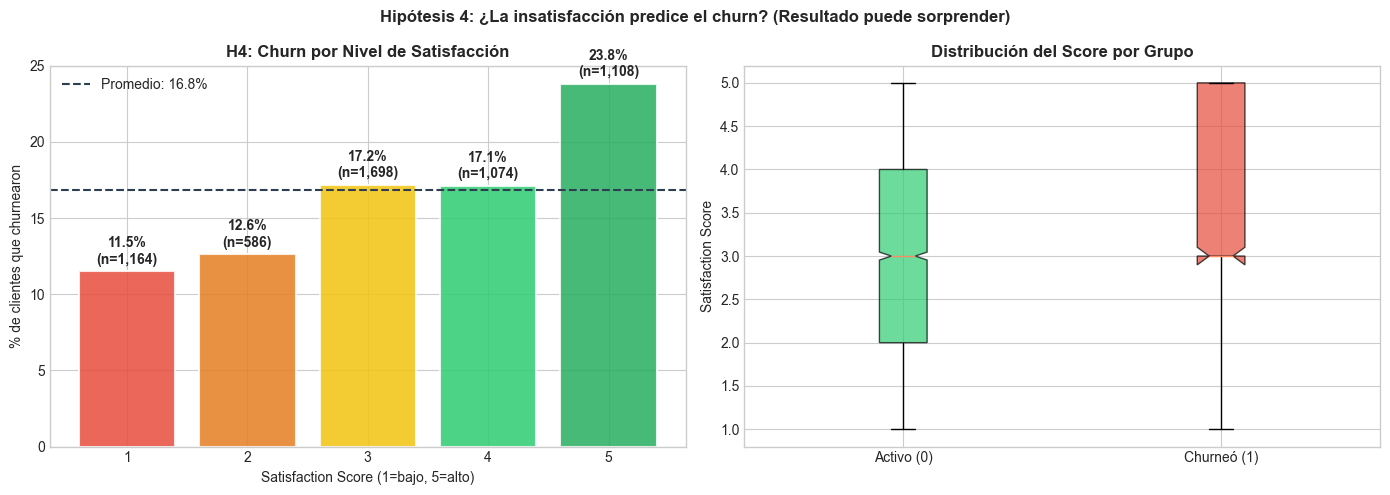

=== TEST ESTADÍSTICO: H4 — SatisfactionScore y Churn ===
Score promedio (activos):    3.00
Score promedio (churneados): 3.39
Mann-Whitney U — p-value: 0.000000
⚠️  RESULTADO CONTRAINTUITIVO: Los churneados tienen score MÁS ALTO.
   Posibles explicaciones: alta satisfacción pero mala retención, o datos con ruido.


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Tasa de churn por score de satisfacción
ax = axes[0]
churn_by_score = df.groupby('SatisfactionScore')['Churn'].agg(['mean', 'count'])
churn_by_score['mean'] *= 100

# Color gradient: rojo para scores bajos (más churn esperado)
score_colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
bars = ax.bar(churn_by_score.index, churn_by_score['mean'].values, 
               color=score_colors, alpha=0.85, edgecolor='white', linewidth=1.5)
ax.axhline(df['Churn'].mean()*100, color='#2c3e50', linestyle='--', linewidth=1.5,
           label=f'Promedio: {df["Churn"].mean()*100:.1f}%')
ax.set_xlabel('Satisfaction Score (1=bajo, 5=alto)')
ax.set_ylabel('% de clientes que churnearon')
ax.set_title('H4: Churn por Nivel de Satisfacción', fontsize=12, fontweight='bold')
ax.legend()
for bar, val, n in zip(bars, churn_by_score['mean'].values, churn_by_score['count'].values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%\n(n={n:,})', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Gráfico 2: Boxplot del score por grupo
ax2 = axes[1]
data_to_plot = [df[df['Churn']==0]['SatisfactionScore'].dropna(),
                df[df['Churn']==1]['SatisfactionScore'].dropna()]
bp = ax2.boxplot(data_to_plot, labels=['Activo (0)', 'Churneó (1)'],
                 patch_artist=True, notch=True)
bp['boxes'][0].set_facecolor(CHURN_COLORS[0])
bp['boxes'][1].set_facecolor(CHURN_COLORS[1])
for box in bp['boxes']:
    box.set_alpha(0.7)
ax2.set_ylabel('Satisfaction Score')
ax2.set_title('Distribución del Score por Grupo', fontsize=12, fontweight='bold')

plt.suptitle('Hipótesis 4: ¿La insatisfacción predice el churn? (Resultado puede sorprender)', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/h4_satisfaccion_churn.png', dpi=150, bbox_inches='tight')
plt.show()

# Test estadístico
grupo_churn = df[df['Churn']==1]['SatisfactionScore'].dropna()
grupo_activo = df[df['Churn']==0]['SatisfactionScore'].dropna()
stat, p_value = stats.mannwhitneyu(grupo_churn, grupo_activo)

print('=== TEST ESTADÍSTICO: H4 — SatisfactionScore y Churn ===')
print(f'Score promedio (activos):    {grupo_activo.mean():.2f}')
print(f'Score promedio (churneados): {grupo_churn.mean():.2f}')
print(f'Mann-Whitney U — p-value: {p_value:.6f}')
if p_value < 0.05:
    if grupo_churn.mean() > grupo_activo.mean():
        print('⚠️  RESULTADO CONTRAINTUITIVO: Los churneados tienen score MÁS ALTO.')
        print('   Posibles explicaciones: alta satisfacción pero mala retención, o datos con ruido.')
    else:
        print('✅ HIPÓTESIS CONFIRMADA: Los churneados tienen menor satisfacción.')
else:
    print('❌ No hay diferencia estadísticamente significativa.')
    print('   La satisfacción por sí sola no discrimina entre los grupos.')

### H5: Clientes con menor cashback tienen más tendencia a irse

**Lógica de negocio:** El cashback es un incentivo financiero para quedarse. Clientes que reciben poco cashback tienen menos "costo de salida" percibido — les resulta más fácil probar otra plataforma.

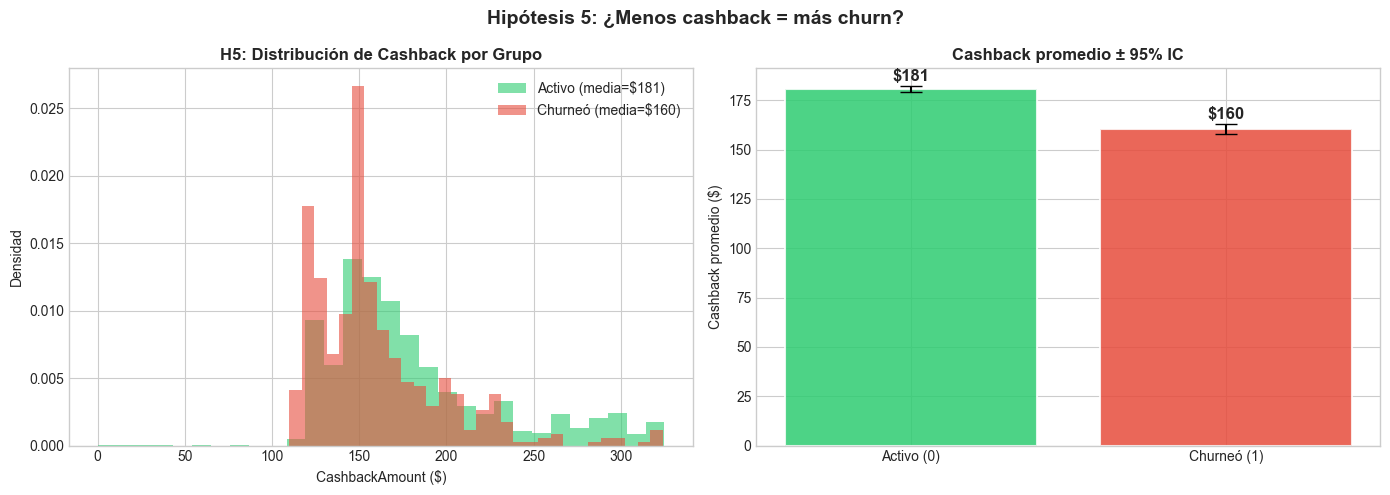

=== TEST ESTADÍSTICO: H5 — CashbackAmount y Churn ===
Cashback promedio (activos):    $181
Cashback promedio (churneados): $160
Mann-Whitney U — p-value: 0.000000
✅ HIPÓTESIS CONFIRMADA: Los que se fueron recibían menos cashback.


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Distribución de CashbackAmount
ax = axes[0]
for churn_val, label in [(0, 'Activo'), (1, 'Churneó')]:
    data = df[df['Churn'] == churn_val]['CashbackAmount'].dropna()
    ax.hist(data, bins=30, alpha=0.6, color=CHURN_COLORS[churn_val], 
            label=f'{label} (media=${data.mean():.0f})', density=True)
ax.set_xlabel('CashbackAmount ($)')
ax.set_ylabel('Densidad')
ax.set_title('H5: Distribución de Cashback por Grupo', fontsize=12, fontweight='bold')
ax.legend()

# Gráfico 2: Medias con intervalo de confianza
ax2 = axes[1]
df_cash = df.groupby('Churn')['CashbackAmount'].agg(['mean', 'sem'])
df_cash['mean'] = df_cash['mean']
x = ['Activo (0)', 'Churneó (1)']
ax2.bar(x, df_cash['mean'].values, 
        yerr=df_cash['sem'].values * 1.96,  # 95% CI
        color=[CHURN_COLORS[0], CHURN_COLORS[1]], alpha=0.85, 
        edgecolor='white', capsize=8, linewidth=1.5)
ax2.set_ylabel('Cashback promedio ($)')
ax2.set_title('Cashback promedio ± 95% IC', fontsize=12, fontweight='bold')
for i, (val, sem) in enumerate(zip(df_cash['mean'].values, df_cash['sem'].values)):
    ax2.text(i, val + sem*1.96 + 1, f'${val:.0f}', ha='center', va='bottom', 
             fontsize=12, fontweight='bold')

plt.suptitle('Hipótesis 5: ¿Menos cashback = más churn?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/h5_cashback_churn.png', dpi=150, bbox_inches='tight')
plt.show()

# Test estadístico
grupo_churn = df[df['Churn']==1]['CashbackAmount'].dropna()
grupo_activo = df[df['Churn']==0]['CashbackAmount'].dropna()
stat, p_value = stats.mannwhitneyu(grupo_churn, grupo_activo, alternative='less')

print('=== TEST ESTADÍSTICO: H5 — CashbackAmount y Churn ===')
print(f'Cashback promedio (activos):    ${grupo_activo.mean():.0f}')
print(f'Cashback promedio (churneados): ${grupo_churn.mean():.0f}')
print(f'Mann-Whitney U — p-value: {p_value:.6f}')
if p_value < 0.05:
    print('✅ HIPÓTESIS CONFIRMADA: Los que se fueron recibían menos cashback.')
else:
    print('❌ No hay evidencia estadística suficiente.')

### H6: Los clientes Single churnean más que casados y divorciados

**Lógica de negocio:** Los clientes solteros suelen tener menor "anclaje" al servicio: compras más impulsivas, menos compras recurrentes para un hogar y un costo de cambio percibido más bajo. Esperamos que el segmento Single muestre una tasa de churn más alta que Married y Divorced.

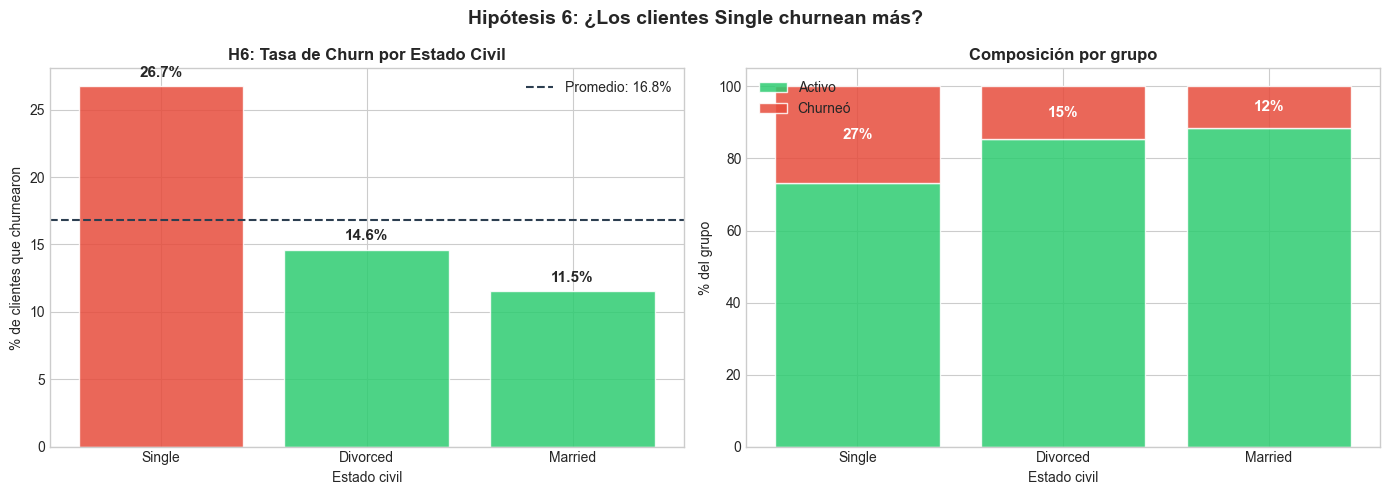

=== TEST ESTADÍSTICO: H6 — MaritalStatus y Churn ===
Single    : churn  26.7%  (n=1,796)
Divorced  : churn  14.6%  (n=848)
Married   : churn  11.5%  (n=2,986)
Chi-cuadrado: 188.7 | dof=2 | p-value: 1.073011e-41
✅ HIPÓTESIS CONFIRMADA: El estado civil se asocia significativamente con el churn.
   Los Single casi duplican la tasa de churn del promedio general.


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
orden = ['Single', 'Divorced', 'Married']

# Gráfico 1: Tasa de churn por estado civil
ax = axes[0]
churn_by_marital = df.groupby('MaritalStatus')['Churn'].mean().reindex(orden) * 100
colors = ['#e74c3c' if x > df['Churn'].mean()*100 else '#2ecc71' for x in churn_by_marital]
bars = ax.bar(churn_by_marital.index, churn_by_marital.values, color=colors, alpha=0.85, edgecolor='white')
ax.axhline(df['Churn'].mean()*100, color='#2c3e50', linestyle='--', linewidth=1.5,
           label=f'Promedio: {df["Churn"].mean()*100:.1f}%')
ax.set_xlabel('Estado civil')
ax.set_ylabel('% de clientes que churnearon')
ax.set_title('H6: Tasa de Churn por Estado Civil', fontsize=12, fontweight='bold')
ax.legend()
for bar, val in zip(bars, churn_by_marital.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Gráfico 2: Composición de cada grupo (activos vs churneados)
ax2 = axes[1]
ct = pd.crosstab(df['MaritalStatus'], df['Churn'], normalize='index').reindex(orden) * 100
ax2.bar(ct.index, ct[0], color=CHURN_COLORS[0], alpha=0.85, label='Activo', edgecolor='white')
ax2.bar(ct.index, ct[1], bottom=ct[0], color=CHURN_COLORS[1], alpha=0.85, label='Churneó', edgecolor='white')
ax2.set_xlabel('Estado civil')
ax2.set_ylabel('% del grupo')
ax2.set_title('Composición por grupo', fontsize=12, fontweight='bold')
ax2.legend()
for i, cat in enumerate(ct.index):
    ax2.text(i, ct.loc[cat, 0] + ct.loc[cat, 1]/2, f'{ct.loc[cat, 1]:.0f}%',
             ha='center', va='center', fontsize=11, fontweight='bold', color='white')

plt.suptitle('Hipótesis 6: ¿Los clientes Single churnean más?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/h6_marital_churn.png', dpi=150, bbox_inches='tight')
plt.show()

# Test estadístico: Chi-cuadrado de independencia (variable categórica vs target)
tabla = pd.crosstab(df['MaritalStatus'], df['Churn'])
chi2, p_value, dof, expected = stats.chi2_contingency(tabla)

print('=== TEST ESTADÍSTICO: H6 — MaritalStatus y Churn ===')
for cat in orden:
    tasa = df[df['MaritalStatus'] == cat]['Churn'].mean() * 100
    n = (df['MaritalStatus'] == cat).sum()
    print(f'{cat:10s}: churn {tasa:5.1f}%  (n={n:,})')
print(f'Chi-cuadrado: {chi2:.1f} | dof={dof} | p-value: {p_value:.6e}')
if p_value < 0.05:
    print('✅ HIPÓTESIS CONFIRMADA: El estado civil se asocia significativamente con el churn.')
    print('   Los Single casi duplican la tasa de churn del promedio general.')
else:
    print('❌ No hay evidencia estadística suficiente.')

**Interpretación de negocio (H6):**  
El segmento **Single concentra el mayor riesgo de churn (~27%, más del doble que Married ~12%)**. Retención debería tratar el estado civil como variable de segmentación: campañas específicas para Single (programas de fidelización, beneficios por recurrencia, recordatorios personalizados) tendrían el mayor impacto marginal. Married es el segmento más estable.

---
## 7. Mapa de correlaciones

Miramos qué variables numéricas se mueven juntas y cuáles se correlacionan con Churn.

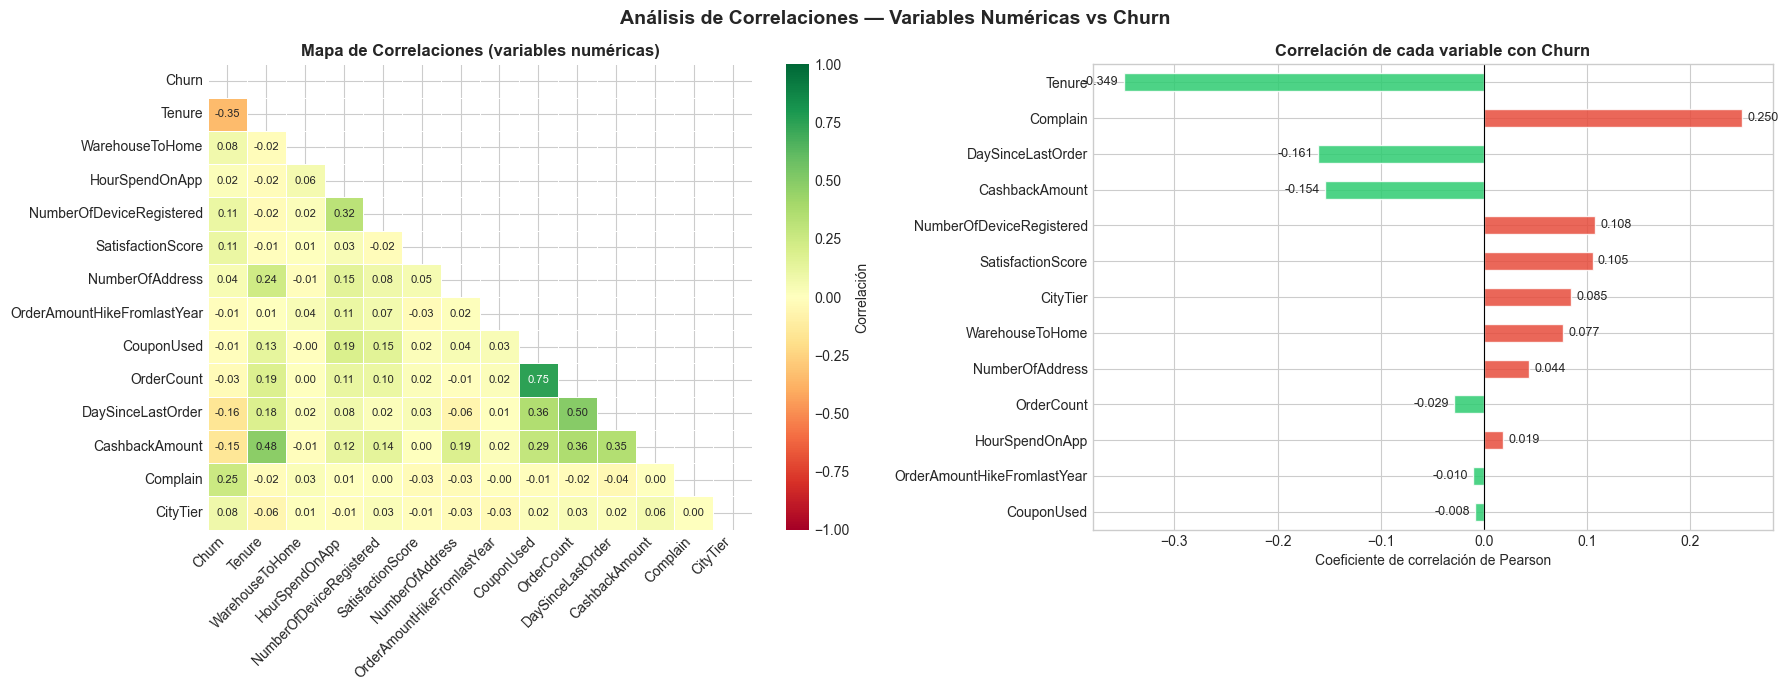


=== Top 5 variables más correlacionadas con Churn ===
Tenure                     0.35
Complain                   0.25
DaySinceLastOrder          0.16
CashbackAmount             0.15
NumberOfDeviceRegistered   0.11
Name: Churn, dtype: float64


In [20]:
# Correlación con la variable target
corr_cols = ['Churn', 'Tenure', 'WarehouseToHome', 'HourSpendOnApp', 
             'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress',
             'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 
             'DaySinceLastOrder', 'CashbackAmount', 'Complain', 'CityTier']

corr_matrix = df[corr_cols].corr()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Heatmap completo
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax1, cbar_kws={'label': 'Correlación'},
            annot_kws={'size': 8})
ax1.set_title('Mapa de Correlaciones (variables numéricas)', fontsize=12, fontweight='bold')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Correlación específica con Churn (barras horizontales)
churn_corr = corr_matrix['Churn'].drop('Churn').sort_values(key=abs, ascending=True)
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in churn_corr]
churn_corr.plot(kind='barh', ax=ax2, color=colors, alpha=0.85, edgecolor='white')
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_title('Correlación de cada variable con Churn', fontsize=12, fontweight='bold')
ax2.set_xlabel('Coeficiente de correlación de Pearson')
for i, (val) in enumerate(churn_corr):
    ax2.text(val + (0.005 if val >= 0 else -0.005), i, 
             f'{val:.3f}', va='center', 
             ha='left' if val >= 0 else 'right', fontsize=9)

plt.suptitle('Análisis de Correlaciones — Variables Numéricas vs Churn', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== Top 5 variables más correlacionadas con Churn ===')
print(churn_corr.abs().sort_values(ascending=False).head(5))

---
## 8. Análisis de segmentos combinados

### Perfil del cliente con mayor riesgo de churn

In [21]:
# Comparación de medias: churneados vs activos
perfil = df.groupby('Churn')[num_cols].mean().T
perfil.columns = ['Activo (0)', 'Churneó (1)']
perfil['Diferencia %'] = ((perfil['Churneó (1)'] - perfil['Activo (0)']) / perfil['Activo (0)'] * 100).round(1)
perfil['Señal'] = perfil['Diferencia %'].apply(lambda x: '🔴 Mayor riesgo' if x > 5 else ('🟢 Menor riesgo' if x < -5 else '⚪ Similar'))

print('=== Perfil comparativo: Churneados vs Activos ===')
print(perfil.to_string())

=== Perfil comparativo: Churneados vs Activos ===
                             Activo (0)  Churneó (1)  Diferencia %           Señal
Tenure                            11.50         3.38        -70.60  🟢 Menor riesgo
WarehouseToHome                   15.35        17.13         11.60  🔴 Mayor riesgo
HourSpendOnApp                     2.93         2.96          1.20       ⚪ Similar
NumberOfDeviceRegistered           3.64         3.93          8.10  🔴 Mayor riesgo
SatisfactionScore                  3.00         3.39         13.00  🔴 Mayor riesgo
NumberOfAddress                    4.16         4.47          7.30  🔴 Mayor riesgo
OrderAmountHikeFromlastYear       15.72        15.63         -0.60       ⚪ Similar
CouponUsed                         1.76         1.72         -2.30       ⚪ Similar
OrderCount                         3.05         2.82         -7.30  🟢 Menor riesgo
DaySinceLastOrder                  4.81         3.24        -32.70  🟢 Menor riesgo
CashbackAmount                   180.

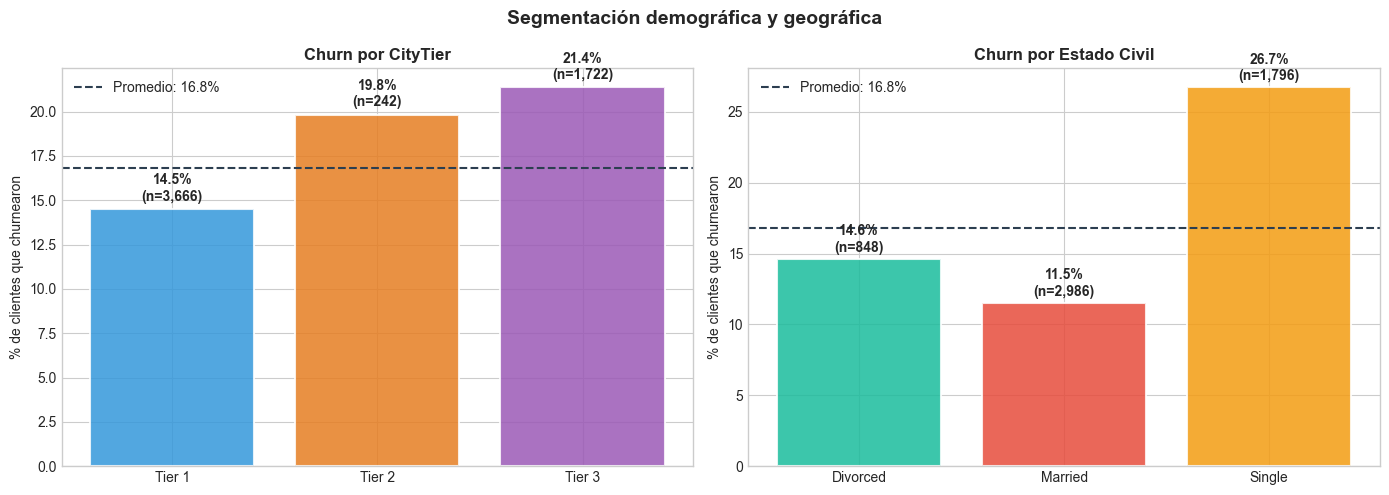

In [22]:
# Segmento de mayor riesgo: Tenure bajo + Complain + SatisfactionScore
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CityTier vs Churn
ax = axes[0]
churn_by_city = df.groupby('CityTier')['Churn'].mean() * 100
count_by_city = df.groupby('CityTier')['Churn'].count()
bars = ax.bar([f'Tier {t}' for t in churn_by_city.index], churn_by_city.values,
               color=['#3498db', '#e67e22', '#9b59b6'], alpha=0.85, edgecolor='white', linewidth=1.5)
ax.axhline(df['Churn'].mean()*100, color='#2c3e50', linestyle='--', linewidth=1.5,
           label=f'Promedio: {df["Churn"].mean()*100:.1f}%')
ax.set_ylabel('% de clientes que churnearon')
ax.set_title('Churn por CityTier', fontsize=12, fontweight='bold')
ax.legend()
for bar, val, n in zip(bars, churn_by_city.values, count_by_city.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%\n(n={n:,})', ha='center', va='bottom', fontsize=10, fontweight='bold')

# MaritalStatus vs Churn
ax2 = axes[1]
churn_by_marital = df.groupby('MaritalStatus')['Churn'].mean() * 100
count_by_marital = df.groupby('MaritalStatus')['Churn'].count()
bars = ax2.bar(churn_by_marital.index, churn_by_marital.values,
               color=['#1abc9c', '#e74c3c', '#f39c12'], alpha=0.85, edgecolor='white', linewidth=1.5)
ax2.axhline(df['Churn'].mean()*100, color='#2c3e50', linestyle='--', linewidth=1.5,
            label=f'Promedio: {df["Churn"].mean()*100:.1f}%')
ax2.set_ylabel('% de clientes que churnearon')
ax2.set_title('Churn por Estado Civil', fontsize=12, fontweight='bold')
ax2.legend()
for bar, val, n in zip(bars, churn_by_marital.values, count_by_marital.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%\n(n={n:,})', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Segmentación demográfica y geográfica', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/segmentacion_demografica.png', dpi=150, bbox_inches='tight')
plt.show()

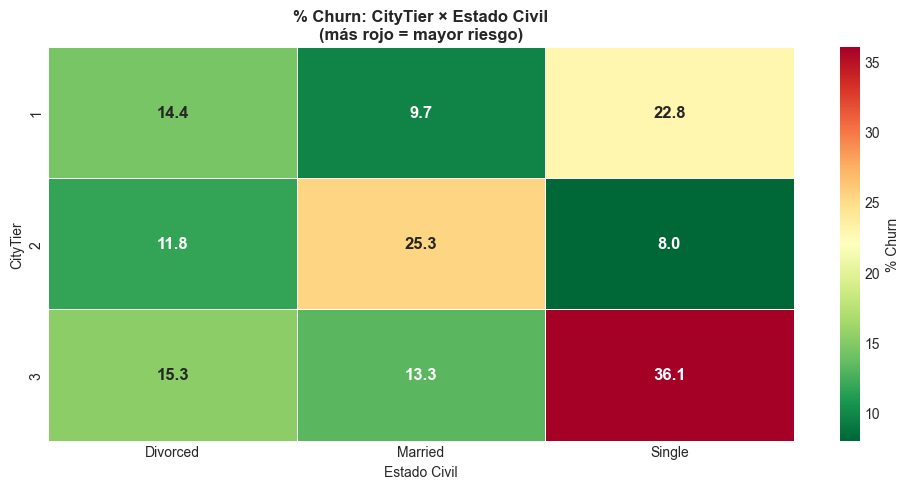


Segmento con MAYOR tasa de churn:
  CityTier=3, MaritalStatus=Single → 36.1% de churn


In [23]:
# Heatmap: Churn por CityTier x MaritalStatus
fig, ax = plt.subplots(figsize=(10, 5))
pivot = df.groupby(['CityTier', 'MaritalStatus'])['Churn'].mean() * 100
pivot = pivot.unstack()

sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r', 
            linewidths=0.5, ax=ax, cbar_kws={'label': '% Churn'},
            annot_kws={'size': 12, 'weight': 'bold'})
ax.set_title('% Churn: CityTier × Estado Civil\n(más rojo = mayor riesgo)', 
             fontsize=12, fontweight='bold')
ax.set_ylabel('CityTier')
ax.set_xlabel('Estado Civil')

plt.tight_layout()
plt.savefig('../reports/heatmap_segmentos.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nSegmento con MAYOR tasa de churn:')
max_segment = pivot.stack().idxmax()
max_val = pivot.stack().max()
print(f'  CityTier={max_segment[0]}, MaritalStatus={max_segment[1]} → {max_val:.1f}% de churn')

---
## 9. Dashboard resumen: Variables más discriminantes

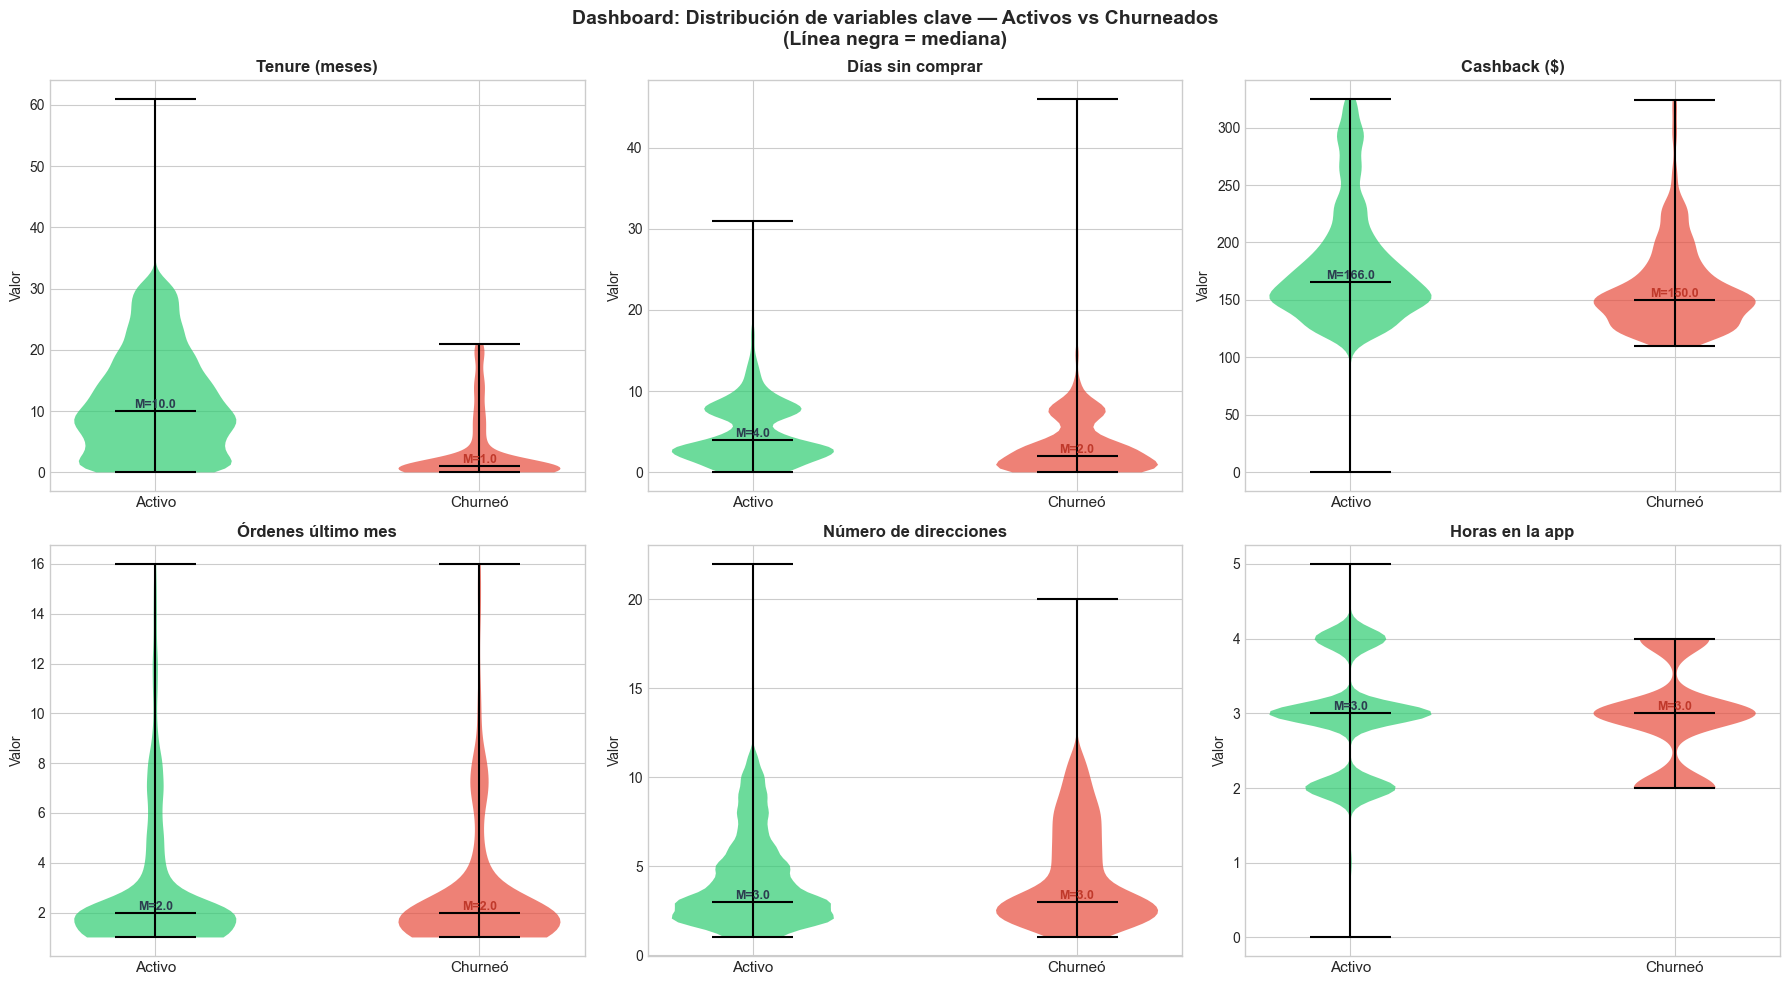

In [24]:
# Dashboard final comparando las variables clave
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

key_vars = [
    ('Tenure', 'Tenure (meses)'),
    ('DaySinceLastOrder', 'Días sin comprar'),
    ('CashbackAmount', 'Cashback ($)'),
    ('OrderCount', 'Órdenes último mes'),
    ('NumberOfAddress', 'Número de direcciones'),
    ('HourSpendOnApp', 'Horas en la app')
]

for i, (col, label) in enumerate(key_vars):
    ax = axes[i]
    
    data0 = df[df['Churn']==0][col].dropna()
    data1 = df[df['Churn']==1][col].dropna()
    
    # Violin plot
    parts = ax.violinplot([data0, data1], positions=[0, 1], 
                          showmedians=True, showmeans=False)
    
    # Colorear
    for pc, color in zip(parts['bodies'], [CHURN_COLORS[0], CHURN_COLORS[1]]):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)
    parts['cmedians'].set_color('black')
    parts['cbars'].set_color('black')
    parts['cmaxes'].set_color('black')
    parts['cmins'].set_color('black')
    
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Activo', 'Churneó'], fontsize=11)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_ylabel('Valor')
    
    # Agregar mediana como texto
    ax.text(0, data0.median(), f'M={data0.median():.1f}', ha='center', va='bottom', 
             fontsize=9, color='#2c3e50', fontweight='bold')
    ax.text(1, data1.median(), f'M={data1.median():.1f}', ha='center', va='bottom', 
             fontsize=9, color='#c0392b', fontweight='bold')

plt.suptitle('Dashboard: Distribución de variables clave — Activos vs Churneados\n(Línea negra = mediana)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/dashboard_variables_clave.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Resumen ejecutivo del EDA

### Lo que encontramos

In [25]:
# Resumen numérico de hallazgos clave
total = len(df)
churn_total = df['Churn'].sum()
churn_pct = df['Churn'].mean() * 100

print('=' * 60)
print('      RESUMEN EJECUTIVO DEL EDA — CHURN DE CLIENTES')
print('=' * 60)
print()
print(f'📊 Dataset: {total:,} clientes | {df.shape[1]} variables')
print(f'🚪 Churn: {churn_total:,} clientes ({churn_pct:.1f}% de la base)')
print()
print('--- HALLAZGOS PRINCIPALES ---')
print()
print('1. CALIDAD DE DATOS')
print('   ⚠️  7 columnas tienen valores nulos (hasta ~15% de nulos en algunas)')
print('   ⚠️  PreferredPaymentMode tenía categorías duplicadas (CC/Credit Card, COD/Cash on Delivery)')
print('   ⚠️  Outliers detectados en Tenure (+50 meses) y WarehouseToHome (+126 km)')
print()
print('2. RESULTADO DE LAS 6 HIPÓTESIS')
print('   ✅ H1 — Tenure: clientes nuevos churnean más (3.4 vs 11.5 meses)')
print('   ✅ H2 — Complain: queja se asocia con churn (⚠️  revisar timing/leakage)')
print('   ❌ H3 — Inactividad: REFUTADA y con relación INVERTIDA (churneados compraron MÁS reciente)')
print('   ⚠️  H4 — Satisfacción: CONTRAINTUITIVO, churneados con score MÁS alto (3.39 vs 3.00)')
print('   ✅ H5 — Cashback: menos cashback = mayor churn ($160 vs $181)')
print('   ✅ H6 — Estado civil: Single churnea ~2x más (26.7% vs 11.5% Married)')
print()
print('3. SEÑALES DE ALERTA PARA ACCIÓN')
print('   🔴 Clientes en primeros 3 meses (Tenure 0-3) tienen el churn más alto')
print('   🔴 Clientes Single concentran el mayor riesgo (casi 2x el promedio)')
print('   🔴 Single en CityTier 3 = segmento con la tasa más alta')
print()
print('4. PRÓXIMOS PASOS (Semana 2-3)')
print('   → Decidir estrategia de imputación de nulos')
print('   → Confirmar timing de la variable Complain con el equipo de datos')
print('   → Investigar el resultado invertido de H3 (nulos/distribución de DaySinceLastOrder)')
print('   → Tratar outliers extremos (WarehouseToHome=126, Tenure=60)')
print('   → Construir modelo baseline (Semana 2)')
print()
print('=' * 60)

      RESUMEN EJECUTIVO DEL EDA — CHURN DE CLIENTES

📊 Dataset: 5,630 clientes | 20 variables
🚪 Churn: 948 clientes (16.8% de la base)

--- HALLAZGOS PRINCIPALES ---

1. CALIDAD DE DATOS
   ⚠️  7 columnas tienen valores nulos (hasta ~15% de nulos en algunas)
   ⚠️  PreferredPaymentMode tenía categorías duplicadas (CC/Credit Card, COD/Cash on Delivery)
   ⚠️  Outliers detectados en Tenure (+50 meses) y WarehouseToHome (+126 km)

2. RESULTADO DE LAS 6 HIPÓTESIS
   ✅ H1 — Tenure: clientes nuevos churnean más (3.4 vs 11.5 meses)
   ✅ H2 — Complain: queja se asocia con churn (⚠️  revisar timing/leakage)
   ❌ H3 — Inactividad: REFUTADA y con relación INVERTIDA (churneados compraron MÁS reciente)
   ⚠️  H4 — Satisfacción: CONTRAINTUITIVO, churneados con score MÁS alto (3.39 vs 3.00)
   ✅ H5 — Cashback: menos cashback = mayor churn ($160 vs $181)
   ✅ H6 — Estado civil: Single churnea ~2x más (26.7% vs 11.5% Married)

3. SEÑALES DE ALERTA PARA ACCIÓN
   🔴 Clientes en primeros 3 meses (Tenure 0

---

## Síntesis de hipótesis (volcada en `reports/01_hipotesis.md`)

| #  | Hipótesis              | Test         | Resultado                                       |
|----|------------------------|--------------|-------------------------------------------------|
| H1 | Tenure bajo → churn    | Mann-Whitney | ✅ Confirmada (3.4 vs 11.5 meses)               |
| H2 | Complain → churn       | Chi-cuadrado | ✅ Confirmada ⚠️ posible leakage                |
| H3 | Inactividad → churn    | Mann-Whitney | ❌ Refutada — relación invertida                |
| H4 | Insatisfacción → churn | Mann-Whitney | ⚠️ Contraintuitivo — churneados más satisfechos |
| H5 | Menor cashback → churn | Mann-Whitney | ✅ Confirmada ($160 vs $181)                    |
| H6 | Single → churn         | Chi-cuadrado | ✅ Confirmada — Single churnea ~2× más          |

**Predictores más fuertes:** Tenure (H1) y MaritalStatus/Single (H6).
**A revisar antes de modelar:** H3 (nulos en DaySinceLastOrder), H4 (ruido en satisfacción), H2 (leakage de Complain).

> El detalle completo (lógica de negocio + acción sugerida por hipótesis) está documentado en `reports/01_hipotesis.md`.
